In [ ]:
!pip install -q pyvista pillow
!apt-get install -y libgl1-mesa-dev xvfb -qq

In [ ]:
# ============================================================
# @title Riemann GCD Fredholm — growing N, 60 fps
# PyVista + ffmpeg pipe + PIL text overlays
#
# Colab setup (run once):
#   !pip install -q pyvista pillow
#   !apt-get install -y libgl1-mesa-dev xvfb -qq
#
# Then just: python3 riemann_growing_N_60fps.py
# ============================================================

import numpy as np
from math import gcd
import subprocess
import warnings
warnings.filterwarnings('ignore')

import os, time, subprocess as _sp
_sp.Popen(['Xvfb', ':99', '-screen', '0', '1920x1080x24'])
time.sleep(1)                      # let Xvfb initialise
os.environ['DISPLAY'] = ':99'

import pyvista as pv
pv.OFF_SCREEN = True               # headless — required on Colab

from matplotlib.colors import hsv_to_rgb
from PIL import Image, ImageDraw, ImageFont

# ── Config ────────────────────────────────────────────────────────────────────
N_MIN  = 1
N_MAX  = 100          # how far to grow — comfortable up to ~200

nx, ny = 80, 62       # field grid — same for all N, never changes
re_min, re_max = -1.8,  2.2
im_min, im_max = -1.6,  1.6
log_clip       = (-5, 4)        # spikes reach H=5, visible from all angles

fps   = 60
HOLD  = 6             # frames held per N step
                      # 6 → 10 N-steps/s  |  12 → 5 N-steps/s  |  3 → 20 N-steps/s

W, H_px = 1920, 1080
OUT     = 'riemann_growing_N_60fps.mp4'

# 4 camera positions (label, eye-xyz) — matching the 4-angle video
CAMERAS = [
    ('UP',    ( 0.2,  0.0,   7.0)),   # top-down
    ('DOWN',  ( 0.2, -5.5,   1.8)),   # low front
    ('LEFT',  (-5.5,  0.0,   2.2)),   # from the left
    ('RIGHT', ( 5.5,  0.0,   2.2)),   # from the right
]

FOCAL = (0.2, 0.0, 0.5)   # center of domain

# ── Math ─────────────────────────────────────────────────────────────────────

def build_gcd_sigma(N):
    idx = np.arange(1, N + 1)
    ii, jj = np.meshgrid(idx, idx, indexing='ij')
    G = np.frompyfunc(gcd, 2, 1)(ii, jj).astype(float)
    return G / np.sqrt(ii * jj)


def elementary_cx(power_sums):
    """Newton identities over C."""
    n = len(power_sums)
    e = np.zeros(n + 1, dtype=complex)
    e[0] = 1.0 + 0j
    for m in range(1, n + 1):
        s = 0j
        for i in range(1, m + 1):
            s += ((-1) ** (i - 1)) * e[m - i] * power_sums[i - 1]
        e[m] = s / m
    return e


def poly_logdet(Zgrid, e, k, eps=1e-300):
    val = np.zeros_like(Zgrid, dtype=complex)
    for j in range(k, -1, -1):
        val = val * Zgrid + ((-1) ** j) * e[j]
    val = np.where(np.abs(val) < eps, eps + 0j, val)
    return np.log(val)


def compute_field(N, theta=0.0):
    """Full field computation for given N and theta."""
    Sigma     = build_gcd_sigma(N)
    evals     = np.sort(np.linalg.eigvalsh(Sigma))[::-1]
    log_ev    = np.log(evals)
    ks        = np.arange(1, N + 1, dtype=float)
    log_outer = np.outer(log_ev, ks)

    s      = np.exp(1j * theta)
    p_k    = np.exp(log_outer * s).sum(axis=0)
    e_k    = elementary_cx(p_k)
    zzeros = np.exp(-s * log_ev)           # z_j(theta) = lambda_j^(-exp(i*theta))

    logdet = poly_logdet(Zgrid, e_k, N)
    logabs = np.real(logdet)
    phase  = np.angle(np.exp(1j * np.imag(logdet)))
    H      = -np.clip(logabs, log_clip[0], log_clip[1])

    return H, phase, zzeros, evals


def phase_to_rgb_points(phase):
    """(ny, nx) phase array -> (ny*nx, 3) uint8 for PyVista point_data."""
    h   = (phase + np.pi) / (2 * np.pi)
    s   = np.full_like(h, 0.88)
    v   = np.full_like(h, 1.00)
    rgb = hsv_to_rgb(np.dstack([h, s, v]))          # (ny, nx, 3) float
    return (rgb.reshape(-1, 3) * 255).astype(np.uint8)


# ── Static geometry ───────────────────────────────────────────────────────────

re_arr = np.linspace(re_min, re_max, nx)
im_arr = np.linspace(im_min, im_max, ny)
X, Y   = np.meshgrid(re_arr, im_arr)
Zgrid  = X + 1j * Y

rcrit   = np.exp(-0.5)
floor_z = -4.6          # just below H_min = -log_clip[1] = -4

th_c      = np.linspace(0, 2 * np.pi, 400)
crit_pts  = np.column_stack([rcrit * np.cos(th_c),
                              rcrit * np.sin(th_c),
                              np.full(400, floor_z)])
unit_pts  = np.column_stack([np.cos(th_c),
                              np.sin(th_c),
                              np.full(400, floor_z)])
crit_line = pv.Spline(crit_pts, 400)
unit_line = pv.Spline(unit_pts, 400)


# ── Annotation text ───────────────────────────────────────────────────────────

_pf_seen = False

def get_annotation(N, evals):
    global _pf_seen
    zeros    = 1.0 / evals
    n_in     = int(np.sum(zeros < rcrit))
    n_out    = int(np.sum(zeros > rcrit))

    if N == 1:
        return "N=1  ·  first zero  ·  one spoke  ·  no structure yet"
    if N == 2:
        return "N=2  ·  two zeros  ·  two spokes  ·  topology begins"
    if N <= 5:
        return f"N={N}  ·  {N} zeros accumulating  ·  spoke structure forming"
    if n_in >= 1 and n_out >= 1 and not _pf_seen:
        _pf_seen = True
        z_in  = zeros[zeros < rcrit].max()
        z_out = zeros[zeros > rcrit].min()
        return (f"★  PF bracket formed  ·  {z_in:.4f} < e^(-½)={rcrit:.4f} < {z_out:.4f}"
                f"  ·  critical circle now bracketed  ·  this is where RH lives")
    if N == 28:
        return "N=28  ·  original configuration  ·  the operator studied throughout this session"
    if N == 50:
        return "N=50  ·  field converging toward infinite-dimensional limit  ·  ζ lives here"
    if N == N_MAX:
        return f"N={N_MAX}  ·  orbit stays open  ·  no invariant pins zeros to critical circle  ·  the wound stays open"
    return (f"N={N}  ·  {len(zeros)} zeros  ·  "
            f"{n_in} inside critical circle  ·  {n_out} outside")


# ── Font setup ────────────────────────────────────────────────────────────────

FONT_PATHS = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
    "/usr/share/fonts/truetype/freefont/FreeMono.ttf",
]

def load_font(size):
    for p in FONT_PATHS:
        try:
            return ImageFont.truetype(p, size)
        except Exception:
            pass
    return ImageFont.load_default()

font_title = load_font(22)
font_note  = load_font(17)
font_small = load_font(13)

BOTTOM = ("green = |z|=e^(-½) critical circle     "
          "orange = |z|=1 unit circle     "
          "pink dots = zeros z_j(θ)     "
          "height = -log|det_k(I-z·Σ^(exp(iθ)))|     "
          "color = arg(det)")


def add_overlay(img_arr, N, annotation):
    img  = Image.fromarray(img_arr)
    draw = ImageDraw.Draw(img)

    # dark strip top
    draw.rectangle([0, 0, W, 44], fill=(0, 0, 0, 200))
    draw.text((W // 2, 6),
              f"GCD Fredholm · growing N · Σ^(exp(iθ)) · θ=0° · det_k(I−z·Σ)",
              font=font_title, fill=(210, 210, 210), anchor='mt')

    # N counter top-right
    draw.text((W - 12, 6),
              f"N = {N:3d} / {N_MAX}",
              font=font_title, fill=(100, 220, 120), anchor='rt')

    # annotation strip bottom
    draw.rectangle([0, H_px - 46, W, H_px], fill=(0, 0, 0, 200))
    draw.text((W // 2, H_px - 30),
              annotation,
              font=font_note, fill=(140, 170, 255), anchor='mb')
    draw.text((W // 2, H_px - 8),
              BOTTOM,
              font=font_small, fill=(70, 70, 70), anchor='mb')

    return np.array(img)


# ── PyVista plotter ───────────────────────────────────────────────────────────

print("Setting up PyVista …")
pl = pv.Plotter(off_screen=True, shape=(2, 2),
                window_size=(W, H_px), border=False)
pl.set_background('black')

# Build initial mesh (N=1) — grid shape never changes
H0, phase0, _, _ = compute_field(1)
mesh = pv.StructuredGrid(X, Y, H0)
mesh.point_data['rgb'] = phase_to_rgb_points(phase0)

# Add static geometry + mesh to all 4 subplots
for idx, (label, eye) in enumerate(CAMERAS):
    row, col = idx // 2, idx % 2
    pl.subplot(row, col)
    pl.add_mesh(mesh, scalars='rgb', rgb=True, lighting=False,
                show_scalar_bar=False, smooth_shading=False)
    pl.add_mesh(crit_line, color='#00ee77', line_width=3,
                render_lines_as_tubes=True)
    pl.add_mesh(unit_line, color='#ff9900', line_width=1.5,
                opacity=0.45, render_lines_as_tubes=True)
    pl.camera.position = tuple(e * 3 for e in eye)
    pl.camera.focal_point = FOCAL
    pl.add_text(label, position='upper_left',
                font_size=9, color='#555555')

# Zero-dot actors (rebuilt each N step — only N_MAX times total, not per frame)
zero_actors = [None] * 4


# ── ffmpeg pipe ───────────────────────────────────────────────────────────────

print("Opening ffmpeg pipe …")
proc = subprocess.Popen([
    'ffmpeg', '-y',
    '-f', 'rawvideo', '-vcodec', 'rawvideo',
    '-s', f'{W}x{H_px}', '-pix_fmt', 'rgb24',
    '-r', str(fps),
    '-i', '-',
    '-c:v', 'h264', '-crf', '16',
    '-preset', 'fast', '-pix_fmt', 'yuv420p',
    OUT
], stdin=subprocess.PIPE, stderr=subprocess.DEVNULL)


# ── Main render loop ──────────────────────────────────────────────────────────

total_frames = (N_MAX - N_MIN + 1) * HOLD
print(f"Rendering N={N_MIN}→{N_MAX} · {fps} fps · {HOLD} frames/step")
print(f"Total frames : {total_frames}")
print(f"Video length : {total_frames / fps:.1f} s")
print()

for N in range(N_MIN, N_MAX + 1):

    if N % 10 == 0 or N <= 5:
        print(f"  N={N:3d}/{N_MAX}")

    # ── compute ──────────────────────────────────────────
    H, phase, zzeros, evals = compute_field(N)

    # ── update surface (in-place, no mesh rebuild) ───────
    mesh.points[:, 2]        = H.ravel()
    mesh.point_data['rgb']   = phase_to_rgb_points(phase)

    # ── update zero scatter (once per N step) ────────────
    zre = np.clip(zzeros.real, re_min, re_max)
    zim = np.clip(zzeros.imag, im_min, im_max)
    zero_pts = np.column_stack([zre, zim, np.full(N, floor_z)])

    for idx in range(4):
        row, col = idx // 2, idx % 2
        pl.subplot(row, col)
        if zero_actors[idx] is not None:
            pl.remove_actor(zero_actors[idx], render=False)
        zero_actors[idx] = pl.add_points(
            zero_pts,
            color='#ff2266',
            point_size=7,
            render_points_as_spheres=True,
        )

    annotation = get_annotation(N, evals)

    # ── hold HOLD frames at this N ───────────────────────
    for _ in range(HOLD):
        raw = pl.screenshot(return_img=True)          # (H_px, W, 3) uint8
        frm = add_overlay(raw, N, annotation)
        proc.stdin.write(frm.tobytes())

# ── finish ────────────────────────────────────────────────────────────────────

proc.stdin.close()
proc.wait()
pl.close()
print(f"\nDone → {OUT}")

Setting up PyVista …
Opening ffmpeg pipe …
Rendering N=1→100 · 60 fps · 6 frames/step
Total frames : 600
Video length : 10.0 s

  N=  1/100
  N=  2/100
  N=  3/100
  N=  4/100
  N=  5/100
  N= 10/100
  N= 20/100
  N= 30/100
  N= 40/100
  N= 50/100
  N= 60/100
  N= 70/100
  N= 80/100
  N= 90/100
  N=100/100

Done → riemann_growing_N_60fps.mp4


In [ ]:
# ============================================================
# @title Riemann GCD Fredholm — growing N + spectral rotation, 60fps
# PyVista + ffmpeg pipe + PIL text overlays
#
# For each N:
#   1. Brief hold at θ=0  — zeros on real axis (the line)
#   2. Full 2π rotation   — zeros leave the line and orbit
#   3. Return to θ=0      — zeros snap back
#   Then N+1
#
# The key question: does the orbit structure change as N grows?
# Does the rotation become more constrained as the operator
# converges toward the infinite-dimensional limit?
#
# Colab setup (run once):
#   !pip install -q pyvista pillow
#   !apt-get install -y libgl1-mesa-dev xvfb -qq
# ============================================================

import numpy as np
from math import gcd
import subprocess, os, time, warnings
warnings.filterwarnings('ignore')

import os, time, subprocess as _sp
_sp.Popen(['Xvfb', ':99', '-screen', '0', '1920x1080x24'])
time.sleep(1)
os.environ['DISPLAY'] = ':99'

import pyvista as pv
pv.OFF_SCREEN = True

from matplotlib.colors import hsv_to_rgb
from PIL import Image, ImageDraw, ImageFont

# ── Config ────────────────────────────────────────────────────────────────────
N_MIN = 1
N_MAX = 100

nx, ny = 80, 62
re_min, re_max = -1.8,  2.2
im_min, im_max = -1.6,  1.6
log_clip        = (-5, 4)

fps              = 60
HOLD             = 4     # frames at θ=0 before rotation  (shows the line)
ROTATION_FRAMES  = 24    # frames per full 2π orbit        (15° per frame)
                         # total per N = 4 + 24 = 28 frames = 0.47s at 60fps
                         # total video = 100 × 28 = 2800 frames = 46.7s

W, H_px = 1920, 1080
OUT     = 'riemann_growing_N_rotation_60fps.mp4'

CAMERAS = [
    ('UP',    ( 0.2,  0.0,   7.0)),
    ('DOWN',  ( 0.2, -5.5,   1.8)),
    ('LEFT',  (-5.5,  0.0,   2.2)),
    ('RIGHT', ( 5.5,  0.0,   2.2)),
]
FOCAL   = (0.2, 0.0, 0.5)

# ── Math ─────────────────────────────────────────────────────────────────────

def build_gcd_sigma(N):
    idx = np.arange(1, N+1)
    ii, jj = np.meshgrid(idx, idx, indexing='ij')
    G = np.frompyfunc(gcd, 2, 1)(ii, jj).astype(float)
    return G / np.sqrt(ii * jj)

def elementary_cx(power_sums):
    n = len(power_sums)
    e = np.zeros(n+1, dtype=complex)
    e[0] = 1.0 + 0j
    for m in range(1, n+1):
        s = 0j
        for i in range(1, m+1):
            s += ((-1)**(i-1)) * e[m-i] * power_sums[i-1]
        e[m] = s / m
    return e

def poly_logdet(Zgrid, e, k, eps=1e-300):
    val = np.zeros_like(Zgrid, dtype=complex)
    for j in range(k, -1, -1):
        val = val * Zgrid + ((-1)**j) * e[j]
    val = np.where(np.abs(val) < eps, eps+0j, val)
    return np.log(val)

def compute_field_fast(log_outer, log_ev, N, theta):
    """Field at given theta — eigenvalues already computed, no matrix rebuild."""
    s      = np.exp(1j * theta)
    p_k    = np.exp(log_outer * s).sum(axis=0)
    e_k    = elementary_cx(p_k)
    zzeros = np.exp(-s * log_ev)          # z_j(θ) = λ_j^(-exp(iθ))
    logdet = poly_logdet(Zgrid, e_k, N)
    logabs = np.real(logdet)
    phase  = np.angle(np.exp(1j * np.imag(logdet)))
    H      = -np.clip(logabs, log_clip[0], log_clip[1])
    return H, phase, zzeros

def phase_to_rgb_points(phase):
    h   = (phase + np.pi) / (2*np.pi)
    s   = np.full_like(h, 0.88)
    v   = np.full_like(h, 1.00)
    rgb = hsv_to_rgb(np.dstack([h, s, v]))
    return (rgb.reshape(-1, 3) * 255).astype(np.uint8)

# ── Grid + static geometry ────────────────────────────────────────────────────
re_arr = np.linspace(re_min, re_max, nx)
im_arr = np.linspace(im_min, im_max, ny)
X, Y   = np.meshgrid(re_arr, im_arr)
Zgrid  = X + 1j*Y

rcrit   = np.exp(-0.5)
floor_z = -4.6

th_c     = np.linspace(0, 2*np.pi, 400)
crit_pts = np.column_stack([rcrit*np.cos(th_c), rcrit*np.sin(th_c), np.full(400, floor_z)])
unit_pts = np.column_stack([np.cos(th_c),       np.sin(th_c),       np.full(400, floor_z)])
crit_line = pv.Spline(crit_pts, 400)
unit_line = pv.Spline(unit_pts, 400)

# θ angles for the rotation part
rotation_angles = np.linspace(0, 2*np.pi, ROTATION_FRAMES, endpoint=False)

# ── Annotation ────────────────────────────────────────────────────────────────
_pf_seen = False

THETA_LABELS = {
    0.00: "θ=0°    zeros on real axis — the line",
    0.25: "θ=90°   all zeros on unit circle — |z_j|=1",
    0.50: "θ=180°  zeros at eigenvalues — inside critical circle",
    0.75: "θ=270°  unit circle — conjugate side",
}

def get_annotation(N, evals, theta):
    global _pf_seen
    zeros  = 1.0 / evals
    n_in   = int(np.sum(zeros < rcrit))
    n_out  = int(np.sum(zeros > rcrit))
    frac   = theta / (2*np.pi)

    theta_tag = ""
    for f, lbl in THETA_LABELS.items():
        if abs(frac - f) < 1.0/ROTATION_FRAMES:
            theta_tag = f"  ·  {lbl}"
            break

    if n_in >= 1 and n_out >= 1 and not _pf_seen:
        _pf_seen = True
        z_in  = zeros[zeros < rcrit].max()
        z_out = zeros[zeros > rcrit].min()
        return (f"★ PF bracket  ·  {z_in:.4f} < e^(-½) < {z_out:.4f}"
                f"  ·  critical circle bracketed{theta_tag}")

    base = f"N={N}  ·  {n_in} zeros inside critical circle  ·  {n_out} outside"
    return base + theta_tag

# ── Font ─────────────────────────────────────────────────────────────────────
def load_font(size):
    for p in ["/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf"]:
        try: return ImageFont.truetype(p, size)
        except: pass
    return ImageFont.load_default()

font_title = load_font(22)
font_note  = load_font(17)
font_small = load_font(13)

BOTTOM = ("green = |z|=e^(-½) critical circle     orange = unit circle |z|=1"
          "     pink=outside  blue=inside critical circle")

def add_overlay(img_arr, N, theta, annotation):
    img  = Image.fromarray(img_arr)
    draw = ImageDraw.Draw(img)

    deg = np.degrees(theta) % 360

    # top bar
    draw.rectangle([0, 0, W, 44], fill=(0,0,0))
    draw.text((W//2, 6),
              f"GCD Fredholm · growing N + spectral rotation · det_k(I−z·Σ^(exp(iθ)))",
              font=font_title, fill=(210,210,210), anchor='mt')
    draw.text((W-12, 6),
              f"N={N:3d}/{N_MAX}  θ={deg:5.1f}°",
              font=font_title, fill=(100,220,120), anchor='rt')

    # bottom bar
    draw.rectangle([0, H_px-46, W, H_px], fill=(0,0,0))
    draw.text((W//2, H_px-30), annotation,
              font=font_note, fill=(140,170,255), anchor='mb')
    draw.text((W//2, H_px-8), BOTTOM,
              font=font_small, fill=(70,70,70), anchor='mb')

    return np.array(img)

# ── PyVista setup ─────────────────────────────────────────────────────────────
print("Setting up PyVista …")
pl = pv.Plotter(off_screen=True, shape=(2,2),
                window_size=(W, H_px), border=False)
pl.set_background('black')

H0, phase0, _, = compute_field_fast(
    np.outer(np.log(np.sort(np.linalg.eigvalsh(build_gcd_sigma(1)))[::-1]),
             np.arange(1,2,dtype=float)),
    np.log(np.sort(np.linalg.eigvalsh(build_gcd_sigma(1)))[::-1]),
    1, 0.0)

mesh = pv.StructuredGrid(X, Y, H0)
mesh.point_data['rgb'] = phase_to_rgb_points(phase0)

for idx, (label, eye) in enumerate(CAMERAS):
    row, col = idx//2, idx%2
    pl.subplot(row, col)
    pl.add_mesh(mesh, scalars='rgb', rgb=True,
                lighting=False, show_scalar_bar=False)
    pl.add_mesh(crit_line, color='#00ee77', line_width=3,
                render_lines_as_tubes=True)
    pl.add_mesh(unit_line, color='#ff9900', line_width=1.5,
                opacity=0.45, render_lines_as_tubes=True)
    pl.camera.position = tuple(e*3 for e in eye)
    pl.camera.focal_point = FOCAL
    pl.add_text(label, position='upper_left', font_size=9, color='#555555')

zero_actors = [None]*4

# ── ffmpeg pipe ───────────────────────────────────────────────────────────────
print("Opening ffmpeg pipe …")
proc = subprocess.Popen([
    'ffmpeg', '-y',
    '-f', 'rawvideo', '-vcodec', 'rawvideo',
    '-s', f'{W}x{H_px}', '-pix_fmt', 'rgb24', '-r', str(fps),
    '-i', '-',
    '-c:v', 'h264', '-crf', '16', '-preset', 'fast', '-pix_fmt', 'yuv420p',
    OUT
], stdin=subprocess.PIPE, stderr=subprocess.DEVNULL)

def render_frame(H, phase, zzeros, N, theta, annotation):
    """Update mesh, update zeros, screenshot, overlay, pipe."""
    mesh.points[:, 2]      = H.ravel()
    mesh.point_data['rgb'] = phase_to_rgb_points(phase)

    # Color zeros by inside/outside critical circle
    zre  = np.clip(zzeros.real, re_min, re_max)
    zim  = np.clip(zzeros.imag, im_min, im_max)
    zmag = np.abs(zzeros)
    zero_pts = np.column_stack([zre, zim, np.full(N, floor_z)])

    for idx in range(4):
        row, col = idx//2, idx%2
        pl.subplot(row, col)
        if zero_actors[idx] is not None:
            pl.remove_actor(zero_actors[idx], render=False)
        # pink = outside critical circle, cyan = inside
        colors = np.where(zmag < rcrit, 0, 1)   # 0=inside, 1=outside
        zero_actors[idx] = pl.add_points(
            zero_pts,
            scalars=colors,
            cmap=['#00ccff', '#ff2266'],          # cyan inside, pink outside
            show_scalar_bar=False,
            point_size=8,
            render_points_as_spheres=True,
        )

    raw = pl.screenshot(return_img=True)
    frm = add_overlay(raw, N, theta, annotation)
    proc.stdin.write(frm.tobytes())

# ── Main loop ─────────────────────────────────────────────────────────────────
total = (N_MAX - N_MIN + 1) * (HOLD + ROTATION_FRAMES)
print(f"Rendering N={N_MIN}→{N_MAX} · {fps}fps")
print(f"Per N: {HOLD} hold + {ROTATION_FRAMES} rotation = {HOLD+ROTATION_FRAMES} frames")
print(f"Total : {total} frames = {total/fps:.1f}s")
print()

for N in range(N_MIN, N_MAX+1):
    if N % 10 == 0 or N <= 5:
        print(f"  N={N:3d}/{N_MAX}")

    # build operator ONCE per N
    Sigma     = build_gcd_sigma(N)
    evals     = np.sort(np.linalg.eigvalsh(Sigma))[::-1]
    log_ev    = np.log(evals)
    ks        = np.arange(1, N+1, dtype=float)
    log_outer = np.outer(log_ev, ks)

    # ── hold at θ=0: show the line ───────────────────────────────────────────
    H0, ph0, zz0 = compute_field_fast(log_outer, log_ev, N, 0.0)
    ann0 = get_annotation(N, evals, 0.0)
    for _ in range(HOLD):
        render_frame(H0, ph0, zz0, N, 0.0, ann0)

    # ── full 2π rotation: watch zeros orbit ──────────────────────────────────
    for theta in rotation_angles:
        H, ph, zz = compute_field_fast(log_outer, log_ev, N, theta)
        ann = get_annotation(N, evals, theta)
        render_frame(H, ph, zz, N, theta, ann)

proc.stdin.close()
proc.wait()
pl.close()
print(f"\nDone → {OUT}")

Setting up PyVista …
Opening ffmpeg pipe …
Rendering N=1→100 · 60fps
Per N: 4 hold + 24 rotation = 28 frames
Total : 2800 frames = 46.7s

  N=  1/100
  N=  2/100
  N=  3/100
  N=  4/100
  N=  5/100
  N= 10/100
  N= 20/100
  N= 30/100
  N= 40/100
  N= 50/100
  N= 60/100
  N= 70/100
  N= 80/100
  N= 90/100
  N=100/100

Done → riemann_growing_N_rotation_60fps.mp4


Saved diagnostic table -> gcd_fredholm_phase_lock_diagnostic.csv

Last-N summary:


,N,theta_deg,cos_theta,inside_critical,on_critical,between_critical_and_unit,on_unit,outside_unit,unit_max_error,unit_mean_error,radial_formula_error,min_radius,max_radius,mean_radius
1683,100,0,1.000000e+00,18,0,8,0,74,2.650648e+01,2.410303e+00,1.110223e-16,0.091438,27.506475,3.164046
1684,100,30,8.660254e-01,15,0,11,0,74,1.664360e+01,1.768338e+00,4.440892e-16,0.125982,17.643601,2.543297
1685,100,45,7.071068e-01,11,0,15,0,74,9.419196e+00,1.207504e+00,2.619432e-16,0.184249,10.419196,2.011057
1686,100,60,5.000000e-01,7,0,19,0,74,4.244662e+00,6.961115e-01,2.428613e-16,0.302387,5.244662,1.543715
1687,100,90,6.123234e-17,0,0,0,100,0,4.440892e-16,7.549517e-17,3.188481e-16,1.000000,1.000000,1.000000
1688,100,120,-5.000000e-01,38,0,36,0,26,2.307019e+00,3.996922e-01,3.330669e-16,0.190670,3.307019,0.868567
1689,100,135,-7.071068e-01,43,0,31,0,26,4.427431e+00,5.500439e-01,3.122502e-16,0.095977,5.427431,0.890679
1690,100,150,-8.660254e-01,47,0,27,0,26,6.937627e+00,6.740161e-01,3.330669e-16,0.056678,7.937627,0.937595
1691,100,180,-1.000000e+00,51,0,23,0,26,9.936372e+00,7.904579e-01,0.000000e+00,0.036355,10.936372,1.000000
1692,100,210,-8.660254e-01,47,0,27,0,26,6.937627e+00,6.740161e-01,2.220446e-16,0.056678,7.937627,0.937595



Angles ranked by closeness to unit circle:


,theta_deg,mean_unit_error,max_unit_error,mean_on_unit,mean_inside_critical,mean_outside_unit
4,90,7.082776e-17,4.440892e-16,50.50,0.00,0.00
12,270,1.884838e-16,7.771561e-16,50.50,0.00,0.00
5,120,3.886428e-01,2.307019e+00,0.03,18.57,13.14
11,240,3.886428e-01,2.307019e+00,0.03,18.57,13.14
6,135,5.352477e-01,4.427431e+00,0.03,22.04,13.14
10,225,5.352477e-01,4.427431e+00,0.03,22.04,13.14
9,210,6.554826e-01,6.937627e+00,0.03,23.66,13.14
7,150,6.554826e-01,6.937627e+00,0.03,23.66,13.14
13,300,6.606554e-01,4.244662e+00,0.03,3.72,37.33
3,60,6.606554e-01,4.244662e+00,0.03,3.72,37.33


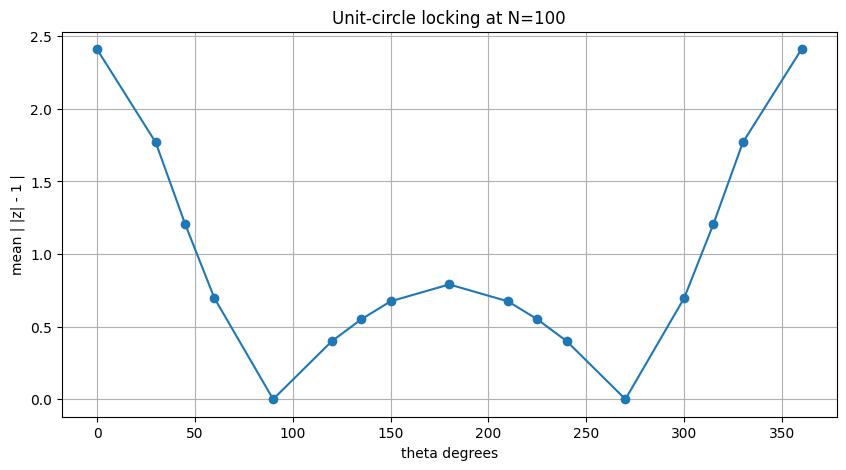

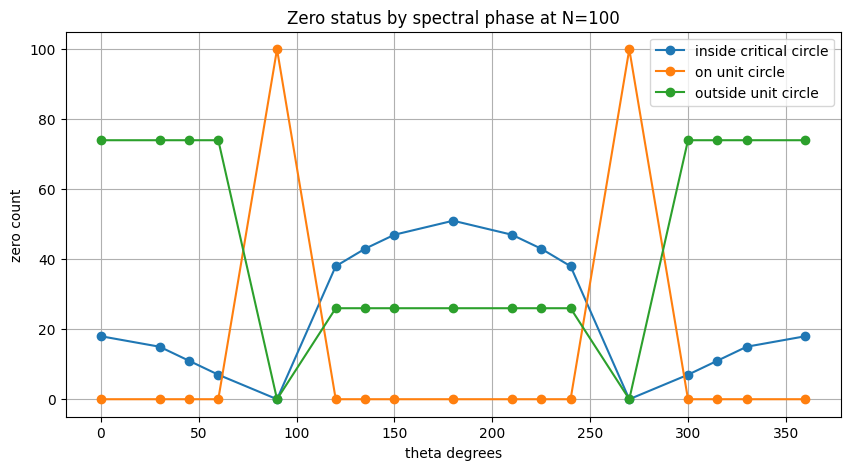

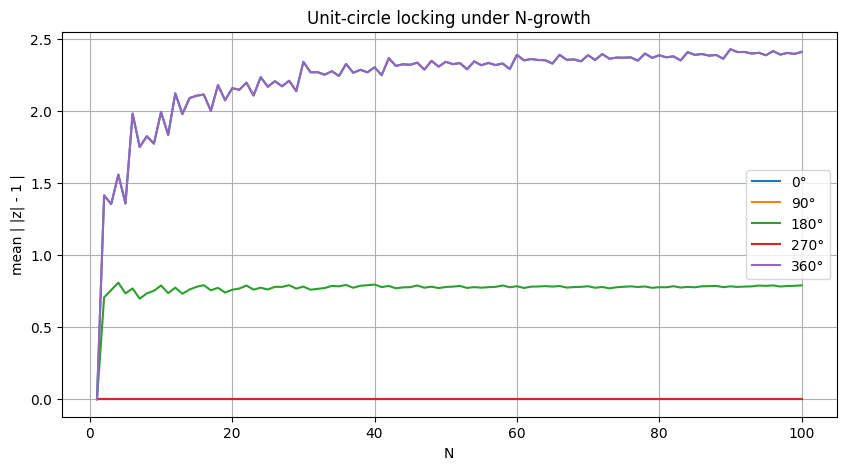


Worst radial formula error:
4.440892098500626e-16
Confirmed: radius is controlled by |z| = exp(-cos(theta) * log(lambda)).

Interpretation:
At theta=90° and theta=270°, cos(theta)=0.
Therefore |z_j|=1 for every eigenvalue lambda_j.
So the unit-circle forcing in this toy is exactly quarter-turn spectral phase locking.


In [ ]:
# ============================================================
# Standalone diagnostic:
# @title GCD Fredholm spectral rotation phase-lock test
#
# Tests:
#   z_j(theta) = exp(-exp(i theta) * log(lambda_j))
#
# Key identity:
#   |z_j(theta)| = exp(-cos(theta) * log(lambda_j))
#
# Therefore:
#   theta = 90° or 270°  -> cos(theta)=0 -> |z_j|=1 for all j
#
# This cell checks whether the apparent "forcing" is exactly
# spectral phase-locking caused by the exp(i theta) exponent.
# ============================================================

import numpy as np
import pandas as pd
from math import gcd
import matplotlib.pyplot as plt

# ----------------------------
# Config
# ----------------------------

N_MIN = 1
N_MAX = 100

# Use dense angles if you want a full sweep.
# For fast structural testing, these are enough:
ANGLES_DEG = [0, 30, 45, 60, 90, 120, 135, 150, 180,
              210, 225, 240, 270, 300, 315, 330, 360]

R_CRIT = np.exp(-0.5)
EPS_UNIT = 1e-10
EPS_PAIR = 1e-8

# ----------------------------
# Operator
# ----------------------------

def build_gcd_sigma(N):
    idx = np.arange(1, N + 1)
    ii, jj = np.meshgrid(idx, idx, indexing="ij")
    G = np.frompyfunc(gcd, 2, 1)(ii, jj).astype(float)
    return G / np.sqrt(ii * jj)

def spectral_zeros_from_evals(evals, theta_rad):
    """
    Your toy's zero rule:
        z_j(theta) = exp(-exp(i theta) * log(lambda_j))
    """
    log_ev = np.log(evals)
    return np.exp(-np.exp(1j * theta_rad) * log_ev)

def summarize_zero_status(N, theta_deg, evals):
    theta = np.deg2rad(theta_deg)
    z = spectral_zeros_from_evals(evals, theta)

    r = np.abs(z)
    arg = np.angle(z)

    inside_crit = int(np.sum(r < R_CRIT))
    on_crit = int(np.sum(np.abs(r - R_CRIT) <= EPS_UNIT))
    between_crit_unit = int(np.sum((r > R_CRIT) & (r < 1 - EPS_UNIT)))
    on_unit = int(np.sum(np.abs(r - 1) <= EPS_UNIT))
    outside_unit = int(np.sum(r > 1 + EPS_UNIT))

    # Main diagnostic: how tightly all zeros sit on |z|=1
    unit_max_error = float(np.max(np.abs(r - 1)))
    unit_mean_error = float(np.mean(np.abs(r - 1)))

    # Theoretical radial multiplier:
    # log |z| = -cos(theta) * log(lambda)
    cos_theta = float(np.cos(theta))
    predicted_log_r = -cos_theta * np.log(evals)
    observed_log_r = np.log(r)
    radial_formula_error = float(np.max(np.abs(observed_log_r - predicted_log_r)))

    return {
        "N": N,
        "theta_deg": theta_deg,
        "cos_theta": cos_theta,
        "inside_critical": inside_crit,
        "on_critical": on_crit,
        "between_critical_and_unit": between_crit_unit,
        "on_unit": on_unit,
        "outside_unit": outside_unit,
        "unit_max_error": unit_max_error,
        "unit_mean_error": unit_mean_error,
        "radial_formula_error": radial_formula_error,
        "min_radius": float(np.min(r)),
        "max_radius": float(np.max(r)),
        "mean_radius": float(np.mean(r)),
    }

# ----------------------------
# Run diagnostic
# ----------------------------

rows = []

for N in range(N_MIN, N_MAX + 1):
    Sigma = build_gcd_sigma(N)

    # GCD matrix is symmetric positive, so eigvalsh is appropriate.
    evals = np.linalg.eigvalsh(Sigma)
    evals = np.sort(evals)[::-1]

    # Numerical safety: avoid log of tiny negative roundoff
    evals = np.maximum(evals, 1e-300)

    for theta_deg in ANGLES_DEG:
        rows.append(summarize_zero_status(N, theta_deg, evals))

df = pd.DataFrame(rows)

# Save results
csv_path = "gcd_fredholm_phase_lock_diagnostic.csv"
df.to_csv(csv_path, index=False)

print(f"Saved diagnostic table -> {csv_path}")
print()
print("Last-N summary:")
display(df[df["N"] == N_MAX].sort_values("theta_deg"))

# ----------------------------
# Find strongest lock angles
# ----------------------------

score = (
    df.groupby("theta_deg")
      .agg(
          mean_unit_error=("unit_mean_error", "mean"),
          max_unit_error=("unit_max_error", "max"),
          mean_on_unit=("on_unit", "mean"),
          mean_inside_critical=("inside_critical", "mean"),
          mean_outside_unit=("outside_unit", "mean"),
      )
      .reset_index()
      .sort_values("mean_unit_error")
)

print()
print("Angles ranked by closeness to unit circle:")
display(score)

# ----------------------------
# Plot 1: unit circle locking by angle
# ----------------------------

last = df[df["N"] == N_MAX].sort_values("theta_deg")

plt.figure(figsize=(10, 5))
plt.plot(last["theta_deg"], last["unit_mean_error"], marker="o")
plt.xlabel("theta degrees")
plt.ylabel("mean | |z| - 1 |")
plt.title(f"Unit-circle locking at N={N_MAX}")
plt.grid(True)
plt.show()

# ----------------------------
# Plot 2: inside/outside status by angle
# ----------------------------

plt.figure(figsize=(10, 5))
plt.plot(last["theta_deg"], last["inside_critical"], marker="o", label="inside critical circle")
plt.plot(last["theta_deg"], last["on_unit"], marker="o", label="on unit circle")
plt.plot(last["theta_deg"], last["outside_unit"], marker="o", label="outside unit circle")
plt.xlabel("theta degrees")
plt.ylabel("zero count")
plt.title(f"Zero status by spectral phase at N={N_MAX}")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 3: growth behavior at key angles
# ----------------------------

key_angles = [0, 90, 180, 270, 360]
sub = df[df["theta_deg"].isin(key_angles)]

plt.figure(figsize=(10, 5))
for theta_deg in key_angles:
    s = sub[sub["theta_deg"] == theta_deg]
    plt.plot(s["N"], s["unit_mean_error"], label=f"{theta_deg}°")

plt.xlabel("N")
plt.ylabel("mean | |z| - 1 |")
plt.title("Unit-circle locking under N-growth")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Explicit identity check
# ----------------------------

worst_formula_error = df["radial_formula_error"].max()
print()
print("Worst radial formula error:")
print(worst_formula_error)

if worst_formula_error < 1e-8:
    print("Confirmed: radius is controlled by |z| = exp(-cos(theta) * log(lambda)).")

print()
print("Interpretation:")
print("At theta=90° and theta=270°, cos(theta)=0.")
print("Therefore |z_j|=1 for every eigenvalue lambda_j.")
print("So the unit-circle forcing in this toy is exactly quarter-turn spectral phase locking.")

Running N=5...
Running N=10...
Running N=15...
Running N=20...
Running N=25...
Running N=30...
Running N=35...
Running N=40...
Running N=45...
Running N=50...
Running N=55...
Running N=60...
Running N=65...
Running N=70...
Running N=75...
Running N=80...
Running N=85...
Running N=90...
Running N=95...
Running N=100...

Saved full diagnostic table -> phase_lock_stress_test.csv
Rows: 15500

Best locking angles by model/noise level:


,model,noise_level,theta_deg,mean_lock_error,max_lock_error,mean_radial_spread,mean_on_unit,max_formula_error
0,eigenvalue_perturbation,0.001,90,7.296321e-17,4.440892e-16,5.162537e-16,52.5,3.318156e-16
1,eigenvalue_perturbation,0.001,270,1.923138e-16,7.771561e-16,9.559020e-16,52.5,3.323405e-16
2,eigenvalue_perturbation,0.001,255,2.178856e-01,8.583407e-01,1.230968e+00,0.0,4.440892e-16
3,eigenvalue_perturbation,0.001,105,2.178856e-01,8.583407e-01,1.230968e+00,0.0,3.330669e-16
4,eigenvalue_perturbation,0.001,285,2.868720e-01,1.358164e+00,1.552018e+00,0.0,3.885781e-16
5,eigenvalue_perturbation,0.010,90,7.233333e-17,4.440892e-16,5.184742e-16,52.5,3.328949e-16
6,eigenvalue_perturbation,0.010,270,1.944915e-16,7.771561e-16,9.736656e-16,52.5,3.319770e-16
7,eigenvalue_perturbation,0.010,255,2.179041e-01,8.591899e-01,1.231510e+00,0.0,3.330669e-16
8,eigenvalue_perturbation,0.010,105,2.179041e-01,8.591899e-01,1.231510e+00,0.0,3.330669e-16
9,eigenvalue_perturbation,0.010,285,2.868579e-01,1.359127e+00,1.552054e+00,0.0,3.885781e-16



Best locking angles at N=100:


,model,noise_level,theta_deg,mean_lock_error,max_lock_error,mean_on_unit,mean_radial_spread
0,eigenvalue_perturbation,0.001,90,7.815970e-17,4.440892e-16,100.0,6.439294e-16
1,eigenvalue_perturbation,0.001,270,1.922906e-16,7.771561e-16,100.0,1.043610e-15
2,eigenvalue_perturbation,0.001,255,2.219167e-01,8.583407e-01,0.0,1.433544e+00
3,eigenvalue_perturbation,0.001,105,2.219167e-01,8.583407e-01,0.0,1.433544e+00
4,eigenvalue_perturbation,0.001,285,2.955781e-01,1.358164e+00,0.0,1.819438e+00
5,eigenvalue_perturbation,0.010,90,7.460699e-17,4.440892e-16,100.0,5.773160e-16
6,eigenvalue_perturbation,0.010,270,1.916245e-16,6.661338e-16,100.0,1.088019e-15
7,eigenvalue_perturbation,0.010,255,2.218240e-01,8.591899e-01,0.0,1.431452e+00
8,eigenvalue_perturbation,0.010,105,2.218240e-01,8.591899e-01,0.0,1.431452e+00
9,eigenvalue_perturbation,0.010,285,2.954344e-01,1.356131e+00,0.0,1.812037e+00


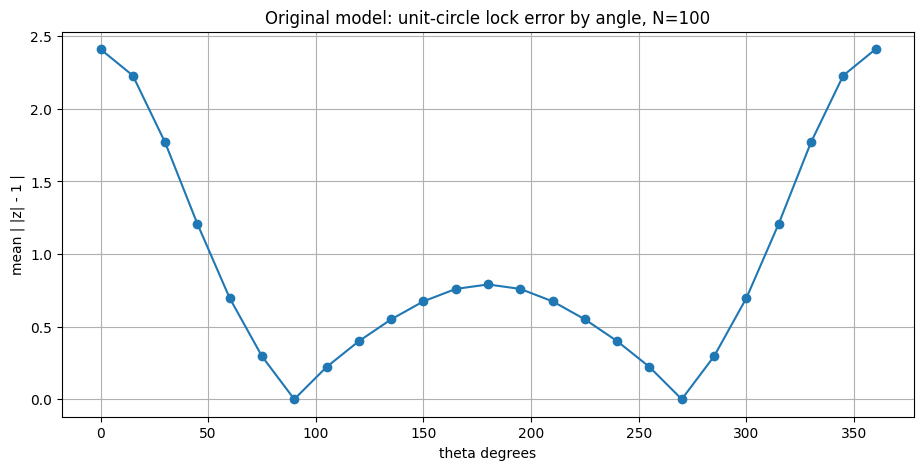

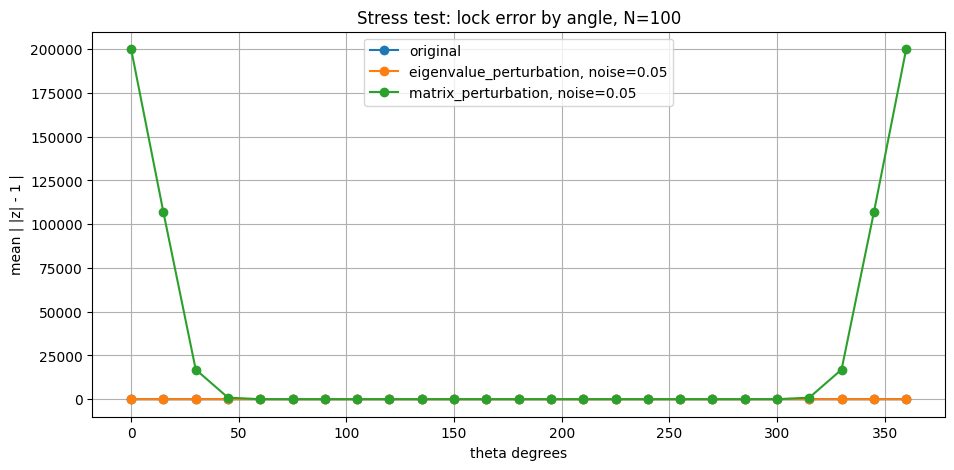

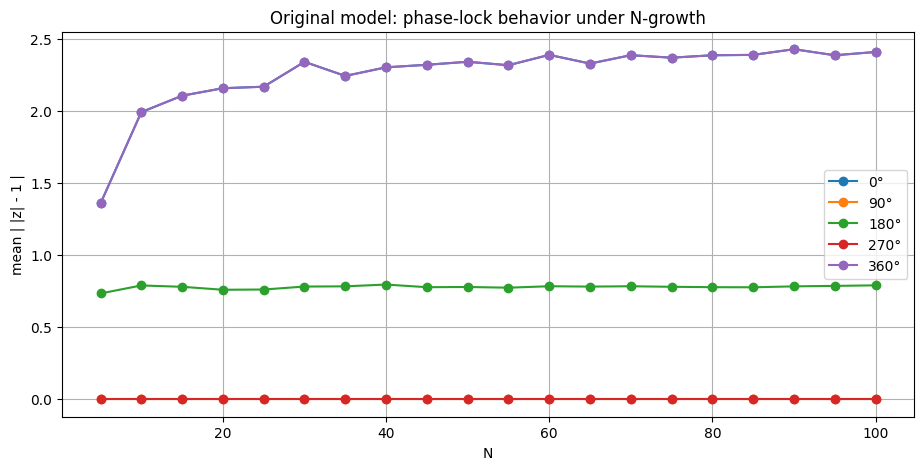

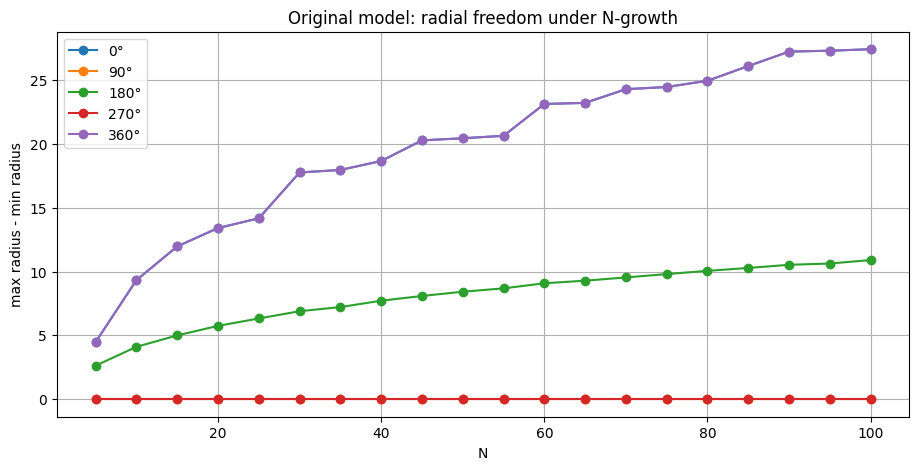


Core checks:
Max lock_error_mean at 90°/270°:
3.108624468950438e-16

Min lock_error_mean away from 90°/270°:
0.18435551085010027

Worst formula error:
4.440892098500626e-16

Result: quarter-turn locking is exact to numerical precision.
Confirmed identity: log |z| = -cos(theta) * log(lambda).

Interpretive target:
If 90°/270° remain perfect under perturbation, the lock is algebraic in the zero map.
If additional angles become competitive only as N grows, that may indicate finite-N structure beyond the built-in quarter-turn rule.
For RH relevance, the useful question is whether a completed-zeta coordinate has an analogous off-line radial mode that a symmetry/status condition cancels.


In [ ]:
# ============================================================
# @title RH-toy diagnostic: phase-lock stress test
#
# Purpose:
#   Test whether special spectral phases remove radial freedom.
#
# Your toy zero rule:
#   z_j(theta) = exp(-exp(i theta) * log(lambda_j))
#
# Key prediction:
#   |z_j(theta)| = exp(-cos(theta) * log(lambda_j))
#
# Therefore:
#   theta = 90° or 270° => cos(theta)=0 => |z_j|=1 for every j
#
# This cell tests:
#   1. original GCD Fredholm spectrum
#   2. eigenvalue perturbations
#   3. matrix perturbations
#   4. growth behavior as N increases
#
# No PyVista. No video. Pure diagnostic table + plots.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd

# ----------------------------
# Config
# ----------------------------

N_VALUES = list(range(5, 105, 5))

ANGLES_DEG = [
    0, 15, 30, 45, 60, 75,
    90,
    105, 120, 135, 150, 165,
    180,
    195, 210, 225, 240, 255,
    270,
    285, 300, 315, 330, 345, 360
]

R_CRIT = np.exp(-0.5)

# perturbation strengths
EIGENVALUE_NOISE_LEVELS = [0.0, 0.001, 0.01, 0.05]
MATRIX_NOISE_LEVELS = [0.0, 0.001, 0.01, 0.05]

# repeat perturbations for stability statistics
TRIALS = 5

# numerical tolerances
EPS_EVAL = 1e-300
EPS_UNIT = 1e-8

rng = np.random.default_rng(12345)

# ----------------------------
# GCD Fredholm operator
# ----------------------------

def build_gcd_sigma(N):
    idx = np.arange(1, N + 1)
    ii, jj = np.meshgrid(idx, idx, indexing="ij")
    G = np.frompyfunc(gcd, 2, 1)(ii, jj).astype(float)
    return G / np.sqrt(ii * jj)

def eigvals_positive_symmetric(A):
    evals = np.linalg.eigvalsh(A)
    evals = np.sort(evals)[::-1]
    return np.maximum(evals, EPS_EVAL)

# ----------------------------
# Perturbation models
# ----------------------------

def perturb_eigenvalues(evals, noise_level, rng):
    """
    Multiplicative log-normal perturbation:
        lambda_j -> lambda_j * exp(noise * normal)
    This preserves positivity.
    """
    if noise_level == 0:
        return evals.copy()
    noise = rng.normal(loc=0.0, scale=noise_level, size=evals.shape)
    out = evals * np.exp(noise)
    return np.maximum(out, EPS_EVAL)

def perturb_matrix_symmetric(Sigma, noise_level, rng):
    """
    Symmetric matrix perturbation:
        Sigma -> Sigma + noise * normalized symmetric random matrix

    Then we shift if needed to keep eigenvalues positive.
    This tests whether the phase lock survives changes to the operator.
    """
    if noise_level == 0:
        return Sigma.copy()

    N = Sigma.shape[0]
    R = rng.normal(size=(N, N))
    R = (R + R.T) / 2.0

    # normalize perturbation relative to Sigma scale
    scale = np.linalg.norm(Sigma, ord="fro") / max(np.linalg.norm(R, ord="fro"), 1e-300)
    A = Sigma + noise_level * scale * R

    # shift to positive definite if numerical/random perturbation creates negatives
    evals = np.linalg.eigvalsh(A)
    min_eval = np.min(evals)
    if min_eval <= EPS_EVAL:
        A = A + (abs(min_eval) + 1e-8) * np.eye(N)

    return A

# ----------------------------
# Zero map and metrics
# ----------------------------

def spectral_zeros_from_evals(evals, theta_rad):
    """
    z_j(theta) = exp(-exp(i theta) * log(lambda_j))
    """
    return np.exp(-np.exp(1j * theta_rad) * np.log(evals))

def zero_metrics(evals, theta_deg):
    theta = np.deg2rad(theta_deg)
    z = spectral_zeros_from_evals(evals, theta)

    r = np.abs(z)
    log_r = np.log(r)

    # Expected formula:
    # log |z| = -cos(theta) * log(lambda)
    predicted_log_r = -np.cos(theta) * np.log(evals)
    formula_error = np.max(np.abs(log_r - predicted_log_r))

    unit_abs_error = np.abs(r - 1.0)

    inside_critical = np.sum(r < R_CRIT)
    on_unit = np.sum(unit_abs_error <= EPS_UNIT)
    outside_unit = np.sum(r > 1.0 + EPS_UNIT)

    radial_spread = np.max(r) - np.min(r)

    # A simple "lock score":
    # lower is better. 0 means perfect unit-circle lock.
    lock_error_max = np.max(unit_abs_error)
    lock_error_mean = np.mean(unit_abs_error)

    return {
        "inside_critical": int(inside_critical),
        "on_unit": int(on_unit),
        "outside_unit": int(outside_unit),
        "min_radius": float(np.min(r)),
        "max_radius": float(np.max(r)),
        "mean_radius": float(np.mean(r)),
        "radial_spread": float(radial_spread),
        "lock_error_max": float(lock_error_max),
        "lock_error_mean": float(lock_error_mean),
        "formula_error": float(formula_error),
    }

# ----------------------------
# Run experiment
# ----------------------------

rows = []

for N in N_VALUES:
    print(f"Running N={N}...")

    Sigma = build_gcd_sigma(N)
    base_evals = eigvals_positive_symmetric(Sigma)

    # 1. original model
    for theta_deg in ANGLES_DEG:
        m = zero_metrics(base_evals, theta_deg)
        rows.append({
            "model": "original",
            "N": N,
            "trial": 0,
            "noise_level": 0.0,
            "theta_deg": theta_deg,
            **m
        })

    # 2. eigenvalue perturbation
    for noise_level in EIGENVALUE_NOISE_LEVELS:
        if noise_level == 0.0:
            continue

        for trial in range(1, TRIALS + 1):
            pevals = perturb_eigenvalues(base_evals, noise_level, rng)

            for theta_deg in ANGLES_DEG:
                m = zero_metrics(pevals, theta_deg)
                rows.append({
                    "model": "eigenvalue_perturbation",
                    "N": N,
                    "trial": trial,
                    "noise_level": noise_level,
                    "theta_deg": theta_deg,
                    **m
                })

    # 3. matrix perturbation
    for noise_level in MATRIX_NOISE_LEVELS:
        if noise_level == 0.0:
            continue

        for trial in range(1, TRIALS + 1):
            P = perturb_matrix_symmetric(Sigma, noise_level, rng)
            pevals = eigvals_positive_symmetric(P)

            for theta_deg in ANGLES_DEG:
                m = zero_metrics(pevals, theta_deg)
                rows.append({
                    "model": "matrix_perturbation",
                    "N": N,
                    "trial": trial,
                    "noise_level": noise_level,
                    "theta_deg": theta_deg,
                    **m
                })

df = pd.DataFrame(rows)

out_csv = "phase_lock_stress_test.csv"
df.to_csv(out_csv, index=False)

print()
print(f"Saved full diagnostic table -> {out_csv}")
print(f"Rows: {len(df)}")

# ----------------------------
# Summary 1:
# Which angles win?
# ----------------------------

summary = (
    df.groupby(["model", "noise_level", "theta_deg"])
      .agg(
          mean_lock_error=("lock_error_mean", "mean"),
          max_lock_error=("lock_error_max", "max"),
          mean_radial_spread=("radial_spread", "mean"),
          mean_on_unit=("on_unit", "mean"),
          max_formula_error=("formula_error", "max"),
      )
      .reset_index()
      .sort_values(["model", "noise_level", "mean_lock_error"])
)

print()
print("Best locking angles by model/noise level:")
display(
    summary.groupby(["model", "noise_level"])
           .head(5)
           .reset_index(drop=True)
)

# ----------------------------
# Summary 2:
# Last N only
# ----------------------------

lastN = max(N_VALUES)

last_summary = (
    df[df["N"] == lastN]
    .groupby(["model", "noise_level", "theta_deg"])
    .agg(
        mean_lock_error=("lock_error_mean", "mean"),
        max_lock_error=("lock_error_max", "max"),
        mean_on_unit=("on_unit", "mean"),
        mean_radial_spread=("radial_spread", "mean"),
    )
    .reset_index()
    .sort_values(["model", "noise_level", "mean_lock_error"])
)

print()
print(f"Best locking angles at N={lastN}:")
display(
    last_summary.groupby(["model", "noise_level"])
                .head(5)
                .reset_index(drop=True)
)

# ----------------------------
# Plot 1:
# original model angle profile at largest N
# ----------------------------

orig_last = df[
    (df["model"] == "original") &
    (df["N"] == lastN)
].sort_values("theta_deg")

plt.figure(figsize=(11, 5))
plt.plot(orig_last["theta_deg"], orig_last["lock_error_mean"], marker="o")
plt.xlabel("theta degrees")
plt.ylabel("mean | |z| - 1 |")
plt.title(f"Original model: unit-circle lock error by angle, N={lastN}")
plt.grid(True)
plt.show()

# ----------------------------
# Plot 2:
# perturbation comparison at largest N
# ----------------------------

plt.figure(figsize=(11, 5))

for model in ["original", "eigenvalue_perturbation", "matrix_perturbation"]:
    sub = df[(df["model"] == model) & (df["N"] == lastN)]

    if model == "original":
        prof = sub.groupby("theta_deg")["lock_error_mean"].mean().reset_index()
        label = "original"
        plt.plot(prof["theta_deg"], prof["lock_error_mean"], marker="o", label=label)
    else:
        # use largest noise level for visual stress
        max_noise = sub["noise_level"].max()
        sub2 = sub[sub["noise_level"] == max_noise]
        prof = sub2.groupby("theta_deg")["lock_error_mean"].mean().reset_index()
        label = f"{model}, noise={max_noise}"
        plt.plot(prof["theta_deg"], prof["lock_error_mean"], marker="o", label=label)

plt.xlabel("theta degrees")
plt.ylabel("mean | |z| - 1 |")
plt.title(f"Stress test: lock error by angle, N={lastN}")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 3:
# growth behavior at key angles
# ----------------------------

key_angles = [0, 90, 180, 270, 360]

plt.figure(figsize=(11, 5))

for theta_deg in key_angles:
    sub = df[
        (df["model"] == "original") &
        (df["theta_deg"] == theta_deg)
    ].sort_values("N")

    plt.plot(sub["N"], sub["lock_error_mean"], marker="o", label=f"{theta_deg}°")

plt.xlabel("N")
plt.ylabel("mean | |z| - 1 |")
plt.title("Original model: phase-lock behavior under N-growth")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 4:
# radial spread under growth
# ----------------------------

plt.figure(figsize=(11, 5))

for theta_deg in key_angles:
    sub = df[
        (df["model"] == "original") &
        (df["theta_deg"] == theta_deg)
    ].sort_values("N")

    plt.plot(sub["N"], sub["radial_spread"], marker="o", label=f"{theta_deg}°")

plt.xlabel("N")
plt.ylabel("max radius - min radius")
plt.title("Original model: radial freedom under N-growth")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Final interpretation checks
# ----------------------------

print()
print("Core checks:")

quarter = df[df["theta_deg"].isin([90, 270])]
nonquarter = df[~df["theta_deg"].isin([90, 270])]

print("Max lock_error_mean at 90°/270°:")
print(quarter["lock_error_mean"].max())

print()
print("Min lock_error_mean away from 90°/270°:")
print(nonquarter["lock_error_mean"].min())

print()
print("Worst formula error:")
print(df["formula_error"].max())

print()
if quarter["lock_error_mean"].max() < 1e-8:
    print("Result: quarter-turn locking is exact to numerical precision.")
else:
    print("Result: quarter-turn locking is not exact; inspect perturbation behavior.")

if df["formula_error"].max() < 1e-8:
    print("Confirmed identity: log |z| = -cos(theta) * log(lambda).")
else:
    print("Warning: radial identity is not matching numerically.")

print()
print("Interpretive target:")
print("If 90°/270° remain perfect under perturbation, the lock is algebraic in the zero map.")
print("If additional angles become competitive only as N grows, that may indicate finite-N structure beyond the built-in quarter-turn rule.")
print("For RH relevance, the useful question is whether a completed-zeta coordinate has an analogous off-line radial mode that a symmetry/status condition cancels.")

Known critical-line zero heights used:
 1: t = 14.134725141735
 2: t = 21.022039638772
 3: t = 25.010857580146
 4: t = 30.424876125860
 5: t = 32.935061587739
 6: t = 37.586178158826
 7: t = 40.918719012147
 8: t = 43.327073280915
 9: t = 48.005150881167
10: t = 49.773832477672
11: t = 52.970321477714
12: t = 56.446247697063
13: t = 59.347044002602
14: t = 60.831778524610
15: t = 65.112544048082
16: t = 67.079810529494
17: t = 69.546401711174
18: t = 72.067157674482
19: t = 75.704690699084
20: t = 77.144840068875

Saved diagnostic table -> zeta_offline_radial_mode_diagnostic.csv
Rows: 3620

Minimum location across off-line displacement a:


,zero_index,t0,a_at_min_abs_xi,sigma_at_min_abs_xi,min_abs_xi
0,1,14.134725,0.0,0.5,1.162467e-18
1,2,21.022040,0.0,0.5,1.812570e-20
2,3,25.010858,0.0,0.5,7.838888e-22
3,4,30.424876,0.0,0.5,1.956469e-23
4,5,32.935062,0.0,0.5,8.133533e-24
5,6,37.586178,0.0,0.5,6.440495e-25
6,7,40.918719,0.0,0.5,3.922690e-26
7,8,43.327073,0.0,0.5,5.888004e-27
8,9,48.005151,0.0,0.5,8.280409e-29
9,10,49.773832,0.0,0.5,2.692935e-29



Max |a_at_min_abs_xi|:
0.0

Off-line growth compared to center:


,zero_index,t0,center_abs_xi,abs_xi_at_+0.05,abs_xi_at_-0.05,ratio_+0.05_to_center,ratio_-0.05_to_center,abs_xi_at_+0.1,abs_xi_at_-0.1,ratio_+0.1_to_center,...,ratio_+0.2_to_center,ratio_-0.2_to_center,abs_xi_at_+0.3,abs_xi_at_-0.3,ratio_+0.3_to_center,ratio_-0.3_to_center,abs_xi_at_+0.4,abs_xi_at_-0.4,ratio_+0.4_to_center,ratio_-0.4_to_center
0,1,14.134725,1.162467e-18,6.914180e-05,6.914180e-05,5.947851e+13,5.947851e+13,1.383187e-04,1.383187e-04,1.189872e+14,...,2.382161e+14,2.382161e+14,4.160806e-04,4.160806e-04,3.579289e+14,3.579289e+14,5.560886e-04,5.560886e-04,4.783693e+14,4.783693e+14
1,2,21.022040,1.812570e-20,8.876429e-07,8.876429e-07,4.897151e+13,4.897151e+13,1.776210e-06,1.776210e-06,9.799402e+13,...,1.963964e+14,1.963964e+14,5.358267e-06,5.358267e-06,2.956171e+14,2.956171e+14,7.179025e-06,7.179025e-06,3.960688e+14,3.960688e+14
2,3,25.010858,7.838888e-22,6.327323e-08,6.327323e-08,8.071710e+13,8.071710e+13,1.266248e-07,1.266248e-07,1.615341e+14,...,3.238679e+14,3.238679e+14,3.823850e-07,3.823850e-07,4.878052e+14,4.878052e+14,5.127868e-07,5.127868e-07,6.541575e+14,6.541575e+14
3,4,30.424876,1.956469e-23,1.206273e-09,1.206273e-09,6.165565e+13,6.165565e+13,2.415061e-09,2.415061e-09,1.234398e+14,...,2.479084e+14,2.479084e+14,7.325778e-09,7.325778e-09,3.744389e+14,3.744389e+14,9.862032e-09,9.862032e-09,5.040731e+14,5.040731e+14
4,5,32.935062,8.133533e-24,2.045342e-10,2.045342e-10,2.514703e+13,2.514703e+13,4.095210e-10,4.095210e-10,5.034971e+13,...,1.011451e+14,1.011451e+14,1.243082e-09,1.243082e-09,1.528342e+14,1.528342e+14,1.674448e-09,1.674448e-09,2.058698e+14,2.058698e+14
5,6,37.586178,6.440495e-25,9.356602e-12,9.356602e-12,1.452777e+13,1.452777e+13,1.873083e-11,1.873083e-11,2.908291e+13,...,5.838511e+13,5.838511e+13,5.675856e-11,5.675856e-11,8.812763e+13,8.812763e+13,7.634239e-11,7.634239e-11,1.185350e+14,1.185350e+14
6,7,40.918719,3.922690e-26,6.100561e-13,6.100561e-13,1.555198e+13,1.555198e+13,1.221817e-12,1.221817e-12,3.114743e+13,...,6.264306e+13,6.264306e+13,3.720199e-12,3.720199e-12,9.483796e+13,9.483796e+13,5.024534e-12,5.024534e-12,1.280890e+14,1.280890e+14
7,8,43.327073,5.888004e-27,1.251001e-13,1.251001e-13,2.124661e+13,2.124661e+13,2.505267e-13,2.505267e-13,4.254866e+13,...,8.554148e+13,8.554148e+13,7.620613e-13,7.620613e-13,1.294261e+14,1.294261e+14,1.028381e-12,1.028381e-12,1.746570e+14,1.746570e+14
8,9,48.005151,8.280409e-29,3.248369e-15,3.248369e-15,3.922958e+13,3.922958e+13,6.509174e-15,6.509174e-15,7.860933e+13,...,1.584211e+14,1.584211e+14,1.992627e-14,1.992627e-14,2.406436e+14,2.406436e+14,2.703528e-14,2.703528e-14,3.264970e+14,3.264970e+14
9,10,49.773832,2.692935e-29,7.807323e-16,7.807323e-16,2.899187e+13,2.899187e+13,1.564693e-15,1.564693e-15,5.810364e+13,...,1.171677e+14,1.171677e+14,4.797720e-15,4.797720e-15,1.781595e+14,1.781595e+14,6.518531e-15,6.518531e-15,2.420605e+14,2.420605e+14



Symmetry error summary:


,zero_index,max_symmetry_error,mean_symmetry_error
0,1,1.210658e-03,6.170717e-04
1,2,1.527669e-05,7.854151e-06
2,3,1.117734e-06,5.671957e-07
3,4,2.030418e-08,1.055698e-08
4,5,3.706736e-09,1.857254e-09
5,6,1.605699e-10,8.267376e-11
6,7,1.056168e-11,5.413911e-12
7,8,2.282374e-12,1.139792e-12
8,9,5.290803e-14,2.797768e-14
9,10,1.455023e-14,7.191033e-15



Worst symmetry error:
0.0012106582358328685


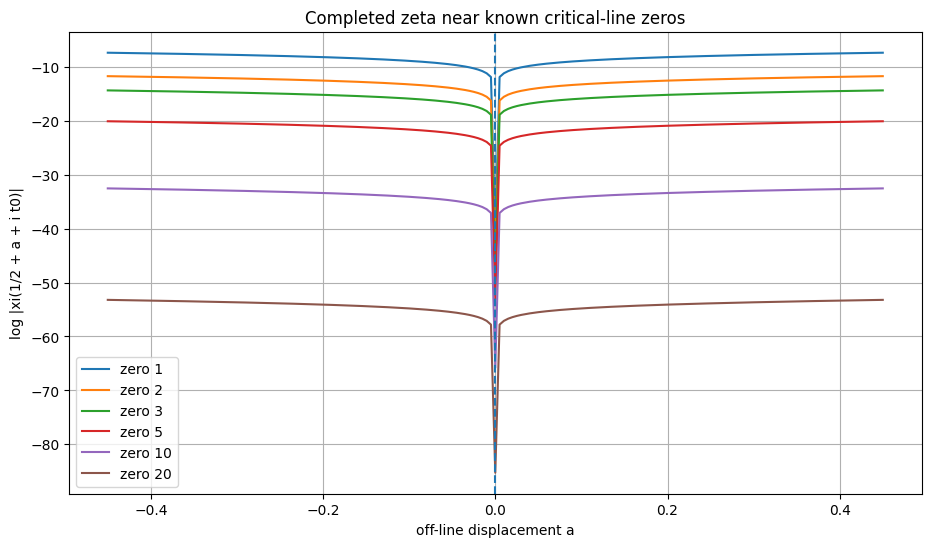

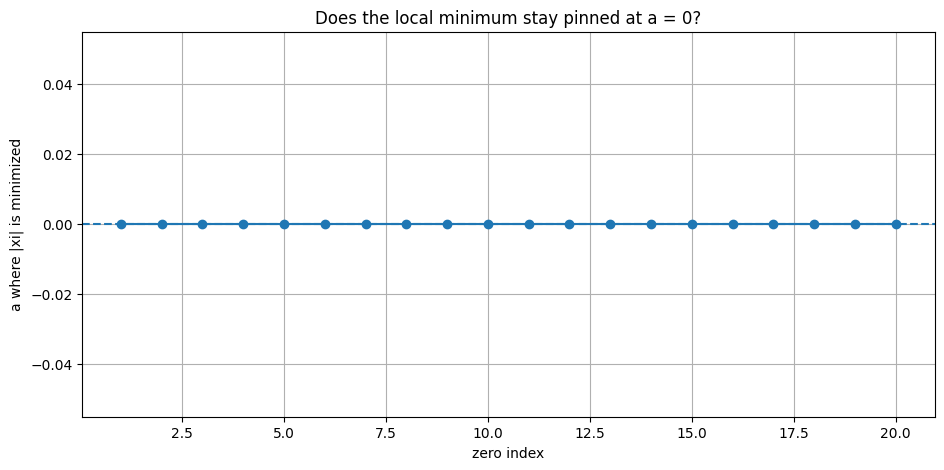

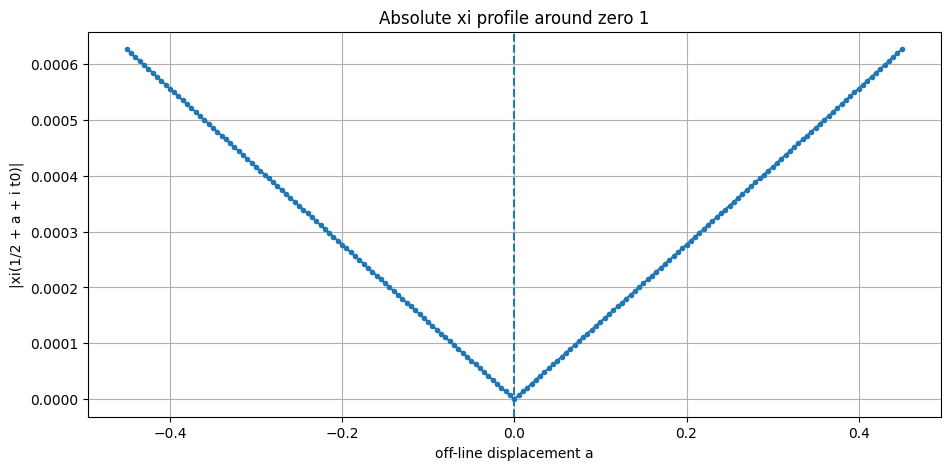


Interpretation guide:

1. If a_at_min_abs_xi is always approximately 0,
   then known critical-line zeros are numerically pinned to the self-dual center.

2. If |xi| grows as |a| moves away from 0,
   then off-line displacement behaves locally like an activated radial mode.

3. This does not rule out unknown off-line zeros elsewhere.
   It only tests the local mechanism around known critical-line zeros.

4. The RH-relevant question becomes:
   Can one prove that this center-pinning is global, not merely local near known zeros?


In [ ]:
# ============================================================
# Zeta-side diagnostic:
# @title Does off-critical displacement behave like a radial mode?
#
# RH target question:
#   What kills a != 0 in s = 1/2 + a + i t?
#
# This cell samples the completed zeta function near known
# critical-line zero heights and checks whether moving away
# from a = 0 activates a symmetric off-line mode.
#
# It tests:
#   1. xi(1/2 + a + it)
#   2. xi(1/2 - a + it)
#   3. symmetry error under a <-> -a
#   4. growth of |xi| as |a| increases from 0
#   5. whether the minimum stays pinned at a = 0
#
# No proof of RH. This is a mechanism diagnostic.
# ============================================================

import mpmath as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mp.mp.dps = 50

# ----------------------------
# Config
# ----------------------------

# Number of known critical-line zeros to test.
NUM_ZEROS = 20

# Off-line displacement values:
# s = 1/2 + a + i t
A_VALUES = np.linspace(-0.45, 0.45, 181)

# Small neighborhood in t around each known zero.
# Set to [0.0] first to test exactly at known zero heights.
T_OFFSETS = [0.0]

# Later, you can use:
# T_OFFSETS = [-0.05, -0.02, -0.01, 0.0, 0.01, 0.02, 0.05]

EPS = 1e-40

# ----------------------------
# Completed zeta / xi function
# ----------------------------

def xi(s):
    """
    Riemann xi function:
        xi(s) = 1/2 * s * (s-1) * pi^(-s/2) * Gamma(s/2) * zeta(s)

    It satisfies:
        xi(s) = xi(1-s)

    This symmetry centers the problem at Re(s)=1/2.
    """
    return mp.mpf("0.5") * s * (s - 1) * mp.power(mp.pi, -s / 2) * mp.gamma(s / 2) * mp.zeta(s)

def safe_log_abs(z):
    return float(mp.log(abs(z) + EPS))

def complex_to_float_abs(z):
    return float(abs(z))

# ----------------------------
# Known critical-line zero heights
# ----------------------------

zero_heights = [float(mp.im(mp.zetazero(n))) for n in range(1, NUM_ZEROS + 1)]

print("Known critical-line zero heights used:")
for i, t in enumerate(zero_heights, start=1):
    print(f"{i:2d}: t = {t:.12f}")

# ----------------------------
# Main sampling
# ----------------------------

rows = []

for zero_index, t0 in enumerate(zero_heights, start=1):
    for dt in T_OFFSETS:
        t = t0 + dt

        for a in A_VALUES:
            s = mp.mpc(0.5 + a, t)
            s_mirror = mp.mpc(0.5 - a, t)

            xi_plus = xi(s)
            xi_minus = xi(s_mirror)

            abs_plus = complex_to_float_abs(xi_plus)
            abs_minus = complex_to_float_abs(xi_minus)

            # Symmetry diagnostic:
            # xi(s) = xi(1-s), while conjugation also relates values
            # because xi has real symmetry.
            symmetry_error = complex_to_float_abs(xi_plus - xi_minus)

            rows.append({
                "zero_index": zero_index,
                "t0": t0,
                "dt": dt,
                "t": t,
                "a": float(a),
                "sigma": float(0.5 + a),
                "abs_xi_plus": abs_plus,
                "abs_xi_minus": abs_minus,
                "log_abs_xi_plus": safe_log_abs(xi_plus),
                "log_abs_xi_minus": safe_log_abs(xi_minus),
                "symmetry_error": symmetry_error,
            })

df = pd.DataFrame(rows)

out_csv = "zeta_offline_radial_mode_diagnostic.csv"
df.to_csv(out_csv, index=False)

print()
print(f"Saved diagnostic table -> {out_csv}")
print(f"Rows: {len(df)}")

# ----------------------------
# Diagnostic 1:
# For each zero, where is |xi| minimized as a varies?
# ----------------------------

min_rows = []

for zero_index in range(1, NUM_ZEROS + 1):
    sub = df[(df["zero_index"] == zero_index) & (df["dt"] == 0.0)].copy()

    # use abs_xi_plus; negative a values are already included
    idx = sub["abs_xi_plus"].idxmin()
    row = sub.loc[idx]

    min_rows.append({
        "zero_index": zero_index,
        "t0": row["t0"],
        "a_at_min_abs_xi": row["a"],
        "sigma_at_min_abs_xi": row["sigma"],
        "min_abs_xi": row["abs_xi_plus"],
    })

mins = pd.DataFrame(min_rows)

print()
print("Minimum location across off-line displacement a:")
display(mins)

print()
print("Max |a_at_min_abs_xi|:")
print(mins["a_at_min_abs_xi"].abs().max())

# ----------------------------
# Diagnostic 2:
# Compare center value to off-center values.
# ----------------------------

summary_rows = []

test_offsets = [0.05, 0.10, 0.20, 0.30, 0.40]

for zero_index in range(1, NUM_ZEROS + 1):
    sub = df[(df["zero_index"] == zero_index) & (df["dt"] == 0.0)].copy()

    center = sub.iloc[(sub["a"].abs()).argmin()]
    center_abs = center["abs_xi_plus"]

    row = {
        "zero_index": zero_index,
        "t0": center["t0"],
        "center_abs_xi": center_abs,
    }

    for a0 in test_offsets:
        pos = sub.iloc[(sub["a"] - a0).abs().argmin()]
        neg = sub.iloc[(sub["a"] + a0).abs().argmin()]

        row[f"abs_xi_at_+{a0}"] = pos["abs_xi_plus"]
        row[f"abs_xi_at_-{a0}"] = neg["abs_xi_plus"]

        # ratio against center. Add EPS to avoid division by zero.
        row[f"ratio_+{a0}_to_center"] = pos["abs_xi_plus"] / (center_abs + EPS)
        row[f"ratio_-{a0}_to_center"] = neg["abs_xi_plus"] / (center_abs + EPS)

    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)

print()
print("Off-line growth compared to center:")
display(summary)

# ----------------------------
# Diagnostic 3:
# Symmetry error under a <-> -a.
# ----------------------------

sym_summary = (
    df[df["dt"] == 0.0]
    .groupby("zero_index")
    .agg(
        max_symmetry_error=("symmetry_error", "max"),
        mean_symmetry_error=("symmetry_error", "mean"),
    )
    .reset_index()
)

print()
print("Symmetry error summary:")
display(sym_summary)

print()
print("Worst symmetry error:")
print(sym_summary["max_symmetry_error"].max())

# ----------------------------
# Plot 1:
# |xi(1/2 + a + it0)| for selected zeros
# ----------------------------

selected = [1, 2, 3, 5, 10, 20]
selected = [z for z in selected if z <= NUM_ZEROS]

plt.figure(figsize=(11, 6))

for zero_index in selected:
    sub = df[(df["zero_index"] == zero_index) & (df["dt"] == 0.0)].sort_values("a")
    plt.plot(sub["a"], sub["log_abs_xi_plus"], label=f"zero {zero_index}")

plt.axvline(0, linestyle="--")
plt.xlabel("off-line displacement a")
plt.ylabel("log |xi(1/2 + a + i t0)|")
plt.title("Completed zeta near known critical-line zeros")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 2:
# Min location by zero index
# ----------------------------

plt.figure(figsize=(11, 5))
plt.plot(mins["zero_index"], mins["a_at_min_abs_xi"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("zero index")
plt.ylabel("a where |xi| is minimized")
plt.title("Does the local minimum stay pinned at a = 0?")
plt.grid(True)
plt.show()

# ----------------------------
# Plot 3:
# Symmetric off-line profile for one zero
# ----------------------------

ZERO_TO_VIEW = 1

sub = df[(df["zero_index"] == ZERO_TO_VIEW) & (df["dt"] == 0.0)].sort_values("a")

plt.figure(figsize=(11, 5))
plt.plot(sub["a"], sub["abs_xi_plus"], marker=".")
plt.axvline(0, linestyle="--")
plt.xlabel("off-line displacement a")
plt.ylabel("|xi(1/2 + a + i t0)|")
plt.title(f"Absolute xi profile around zero {ZERO_TO_VIEW}")
plt.grid(True)
plt.show()

# ----------------------------
# Interpretation
# ----------------------------

print()
print("Interpretation guide:")
print()
print("1. If a_at_min_abs_xi is always approximately 0,")
print("   then known critical-line zeros are numerically pinned to the self-dual center.")
print()
print("2. If |xi| grows as |a| moves away from 0,")
print("   then off-line displacement behaves locally like an activated radial mode.")
print()
print("3. This does not rule out unknown off-line zeros elsewhere.")
print("   It only tests the local mechanism around known critical-line zeros.")
print()
print("4. The RH-relevant question becomes:")
print("   Can one prove that this center-pinning is global, not merely local near known zeros?")

Scanning 801 x 197 = 157,797 points...
This may take a bit depending on precision and machine speed.
  t row 0/801  t=0.000
  t row 50/801  t=5.000
  t row 100/801  t=10.000
  t row 150/801  t=15.000
  t row 200/801  t=20.000
  t row 250/801  t=25.000
  t row 300/801  t=30.000
  t row 350/801  t=35.000
  t row 400/801  t=40.000
  t row 450/801  t=45.000
  t row 500/801  t=50.000
  t row 550/801  t=55.000
  t row 600/801  t=60.000
  t row 650/801  t=65.000
  t row 700/801  t=70.000
  t row 750/801  t=75.000
  t row 800/801  t=80.000
Scan complete.

Saved full scan table -> zeta_wide_offline_valley_scan.csv

Candidate count:
21

Strongest candidates:


,t,a,sigma,log_abs_xi,spike_height,abs_a,kind
0,79.3,0.0,0.5,-56.845997,56.845997,0.0,local_minimum
1,75.7,0.0,0.5,-56.552810,56.552810,0.0,local_minimum
2,77.1,0.0,0.5,-55.579843,55.579843,0.0,local_minimum
3,72.1,0.0,0.5,-51.351457,51.351457,0.0,local_minimum
4,69.5,0.0,0.5,-49.343084,49.343084,0.0,local_minimum
5,67.1,0.0,0.5,-48.548531,48.548531,0.0,local_minimum
6,65.1,0.0,0.5,-47.254779,47.254779,0.0,local_minimum
7,60.8,0.0,0.5,-43.416432,43.416432,0.0,local_minimum
8,59.3,0.0,0.5,-42.026030,42.026030,0.0,local_minimum
9,56.4,0.0,0.5,-39.332721,39.332721,0.0,local_minimum



Best-a summary:


,t,best_a,best_sigma,best_log_abs_xi,best_spike_height,best_abs_a
793,79.3,0.0,0.5,-56.845997,56.845997,0.0
757,75.7,0.0,0.5,-56.552810,56.552810,0.0
794,79.4,0.0,0.5,-56.372342,56.372342,0.0
771,77.1,0.0,0.5,-55.579843,55.579843,0.0
792,79.2,0.0,0.5,-55.507095,55.507095,0.0
795,79.5,0.0,0.5,-55.465711,55.465711,0.0
772,77.2,0.0,0.5,-55.418818,55.418818,0.0
796,79.6,0.0,0.5,-55.039085,55.039085,0.0
791,79.1,0.0,0.5,-54.928502,54.928502,0.0
797,79.7,0.0,0.5,-54.773990,54.773990,0.0



Rows where best point is meaningfully off-center:


,t,center_a,center_log_abs_xi,center_spike_height,best_a,best_sigma,best_log_abs_xi,best_spike_height,best_minus_center_log,best_abs_a


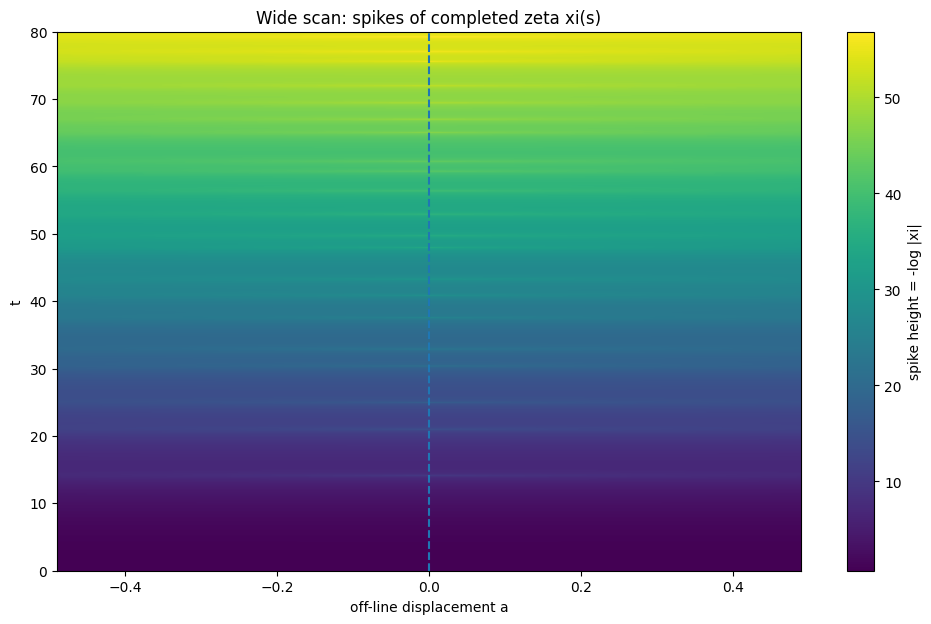

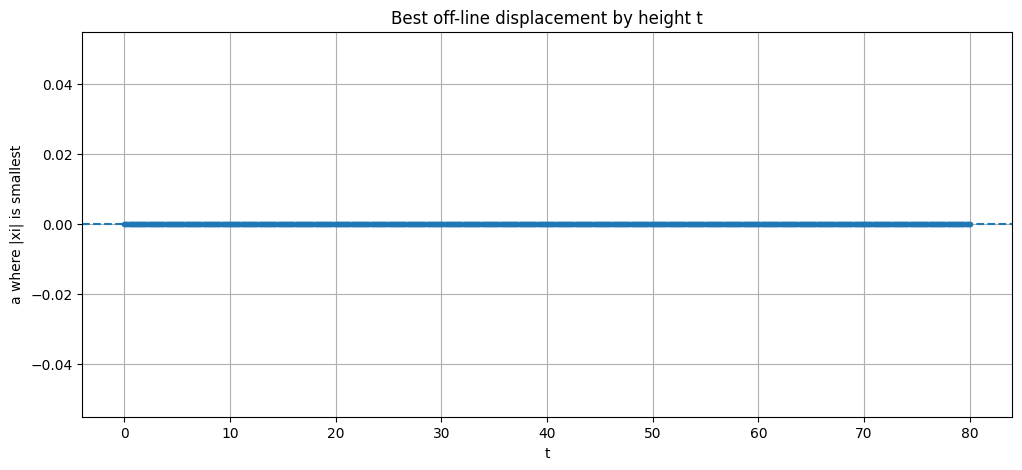

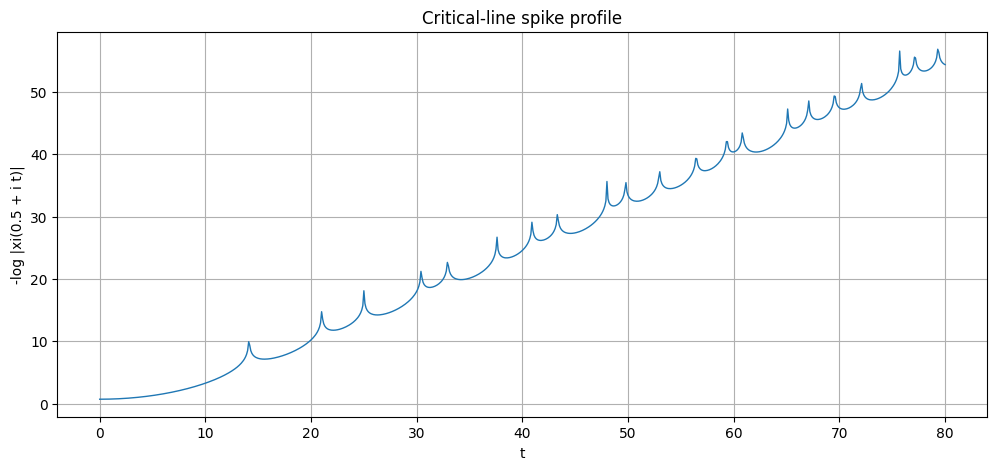

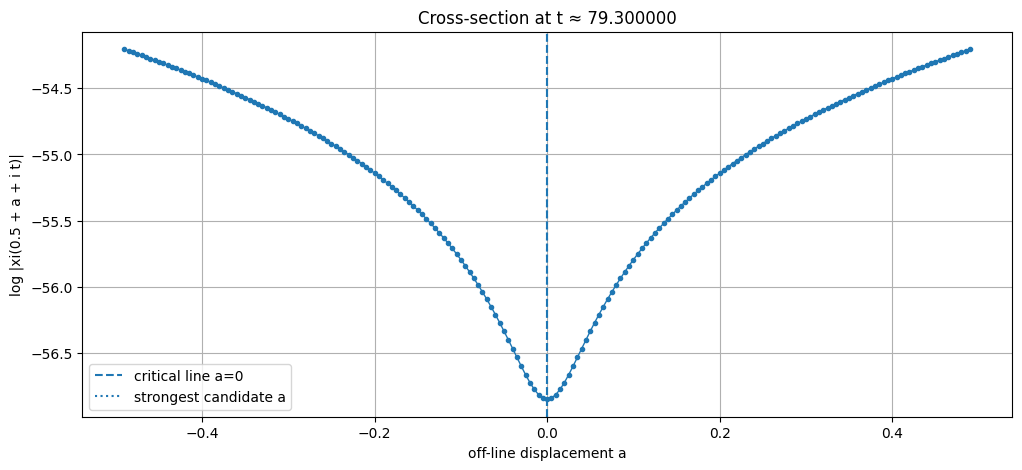


Interpretation guide:

A true or near off-line zero would show as a deep valley in log|xi|
at a != 0, equivalently a spike in -log|xi| away from the center line.

If the strongest valleys occur at a ≈ 0, that supports the usual
critical-line pinning numerically over this scanned range.

If a deep local minimum appears at a != 0, that is not automatically
a counterexample. It needs refinement with higher precision and local
root-finding. But it would be the exact type of candidate to investigate.

Main RH-relevant question:
Does the best/true zero-status ever occur with a nonzero off-line mode?


In [ ]:
# ============================================================
# @title Wide off-line valley / spike scan for completed zeta xi(s)
#
# RH-relevant diagnostic:
#   Search the critical strip for valleys of |xi(s)| away from
#   the critical line.
#
# Coordinate:
#   s = 1/2 + a + i t
#
# Critical line:
#   a = 0
#
# Off-line zero would appear as:
#   a != 0 and |xi(1/2 + a + i t)| ≈ 0
#
# Visualization logic:
#   valley in |xi|  <=>  spike in -log|xi|
#
# This is not a proof of RH.
# It is a numerical scan for off-line near-zero candidates.
# ============================================================

import mpmath as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mp.mp.dps = 50

# ----------------------------
# Config
# ----------------------------

# Scan range in t.
# Start modest. Increase after the cell works.
T_MIN = 0.0
T_MAX = 80.0
T_POINTS = 801

# Off-line displacement a.
# Since sigma must stay in the critical strip:
#   sigma = 0.5 + a
#   0 < sigma < 1
# so:
#   -0.5 < a < 0.5
A_MIN = -0.49
A_MAX = 0.49
A_POINTS = 197

# Numerical floor for logs
EPS = mp.mpf("1e-80")

# Candidate thresholds.
# Smaller log_abs_xi means closer to zero.
# You can adjust after seeing output.
CANDIDATE_LOG_THRESHOLD = -8.0

# For local-minimum detection:
# point must be lower than its 8 grid neighbors.
USE_LOCAL_MINIMA = True

# Output
OUT_CSV = "zeta_wide_offline_valley_scan.csv"

# ----------------------------
# Completed zeta / xi function
# ----------------------------

def xi(s):
    """
    Riemann xi function:
        xi(s) = 1/2 * s * (s-1) * pi^(-s/2) * Gamma(s/2) * zeta(s)

    Symmetry:
        xi(s) = xi(1-s)
    """
    return (
        mp.mpf("0.5")
        * s
        * (s - 1)
        * mp.power(mp.pi, -s / 2)
        * mp.gamma(s / 2)
        * mp.zeta(s)
    )

def log_abs_xi(a, t):
    s = mp.mpc(mp.mpf("0.5") + mp.mpf(str(a)), mp.mpf(str(t)))
    val = xi(s)
    return float(mp.log(abs(val) + EPS))

# ----------------------------
# Grid scan
# ----------------------------

a_values = np.linspace(A_MIN, A_MAX, A_POINTS)
t_values = np.linspace(T_MIN, T_MAX, T_POINTS)

Z = np.empty((T_POINTS, A_POINTS), dtype=float)

print(f"Scanning {T_POINTS} x {A_POINTS} = {T_POINTS * A_POINTS:,} points...")
print("This may take a bit depending on precision and machine speed.")

for i, t in enumerate(t_values):
    if i % 50 == 0:
        print(f"  t row {i}/{T_POINTS}  t={t:.3f}")

    for j, a in enumerate(a_values):
        Z[i, j] = log_abs_xi(a, t)

print("Scan complete.")

# ----------------------------
# Convert to table
# ----------------------------

rows = []

for i, t in enumerate(t_values):
    for j, a in enumerate(a_values):
        rows.append({
            "t": float(t),
            "a": float(a),
            "sigma": float(0.5 + a),
            "log_abs_xi": float(Z[i, j]),
            "spike_height": float(-Z[i, j]),
            "abs_a": float(abs(a)),
        })

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

print()
print(f"Saved full scan table -> {OUT_CSV}")

# ----------------------------
# Candidate detection
# ----------------------------

candidate_mask = Z < CANDIDATE_LOG_THRESHOLD

candidates = []

if USE_LOCAL_MINIMA:
    for i in range(1, T_POINTS - 1):
        for j in range(1, A_POINTS - 1):
            center = Z[i, j]

            if center >= CANDIDATE_LOG_THRESHOLD:
                continue

            neighborhood = Z[i-1:i+2, j-1:j+2].copy()
            neighborhood[1, 1] = np.inf

            if center < np.min(neighborhood):
                candidates.append({
                    "t": float(t_values[i]),
                    "a": float(a_values[j]),
                    "sigma": float(0.5 + a_values[j]),
                    "log_abs_xi": float(center),
                    "spike_height": float(-center),
                    "abs_a": float(abs(a_values[j])),
                    "kind": "local_minimum",
                })
else:
    idxs = np.argwhere(candidate_mask)
    for i, j in idxs:
        candidates.append({
            "t": float(t_values[i]),
            "a": float(a_values[j]),
            "sigma": float(0.5 + a_values[j]),
            "log_abs_xi": float(Z[i, j]),
            "spike_height": float(-Z[i, j]),
            "abs_a": float(abs(a_values[j])),
            "kind": "threshold",
        })

cand = pd.DataFrame(candidates)

if len(cand) > 0:
    cand = cand.sort_values("log_abs_xi").reset_index(drop=True)
    cand.to_csv("zeta_wide_offline_candidates.csv", index=False)

print()
print("Candidate count:")
print(len(cand))

if len(cand) > 0:
    print()
    print("Strongest candidates:")
    display(cand.head(30))
else:
    print("No candidates below threshold.")

# ----------------------------
# For each t, find best a
# ----------------------------

best_by_t_rows = []

for i, t in enumerate(t_values):
    j_min = int(np.argmin(Z[i, :]))
    best_by_t_rows.append({
        "t": float(t),
        "best_a": float(a_values[j_min]),
        "best_sigma": float(0.5 + a_values[j_min]),
        "best_log_abs_xi": float(Z[i, j_min]),
        "best_spike_height": float(-Z[i, j_min]),
        "best_abs_a": float(abs(a_values[j_min])),
    })

best_by_t = pd.DataFrame(best_by_t_rows)
best_by_t.to_csv("zeta_wide_best_a_by_t.csv", index=False)

print()
print("Best-a summary:")
display(best_by_t.sort_values("best_log_abs_xi").head(30))

# ----------------------------
# Central-line comparison
# ----------------------------

# Find grid index closest to a=0
j_center = int(np.argmin(np.abs(a_values)))

center_rows = []

for i, t in enumerate(t_values):
    center_log = Z[i, j_center]
    best_log = np.min(Z[i, :])
    best_j = int(np.argmin(Z[i, :]))

    center_rows.append({
        "t": float(t),
        "center_a": float(a_values[j_center]),
        "center_log_abs_xi": float(center_log),
        "center_spike_height": float(-center_log),
        "best_a": float(a_values[best_j]),
        "best_sigma": float(0.5 + a_values[best_j]),
        "best_log_abs_xi": float(best_log),
        "best_spike_height": float(-best_log),
        "best_minus_center_log": float(best_log - center_log),
        "best_abs_a": float(abs(a_values[best_j])),
    })

center_compare = pd.DataFrame(center_rows)
center_compare.to_csv("zeta_wide_center_compare.csv", index=False)

print()
print("Rows where best point is meaningfully off-center:")
off_center_best = center_compare[
    (center_compare["best_abs_a"] > 0.01) &
    (center_compare["best_log_abs_xi"] < CANDIDATE_LOG_THRESHOLD)
].sort_values("best_log_abs_xi")

display(off_center_best.head(30))

# ----------------------------
# Plot 1:
# Heatmap of spike height = -log |xi|
# ----------------------------

plt.figure(figsize=(12, 7))
plt.imshow(
    -Z,
    extent=[A_MIN, A_MAX, T_MIN, T_MAX],
    origin="lower",
    aspect="auto",
)
plt.colorbar(label="spike height = -log |xi|")
plt.axvline(0, linestyle="--")
plt.xlabel("off-line displacement a")
plt.ylabel("t")
plt.title("Wide scan: spikes of completed zeta xi(s)")
plt.show()

# ----------------------------
# Plot 2:
# Best a as a function of t
# ----------------------------

plt.figure(figsize=(12, 5))
plt.plot(best_by_t["t"], best_by_t["best_a"], marker=".", linewidth=1)
plt.axhline(0, linestyle="--")
plt.xlabel("t")
plt.ylabel("a where |xi| is smallest")
plt.title("Best off-line displacement by height t")
plt.grid(True)
plt.show()

# ----------------------------
# Plot 3:
# Center spike profile by t
# ----------------------------

plt.figure(figsize=(12, 5))
plt.plot(center_compare["t"], center_compare["center_spike_height"], linewidth=1)
plt.xlabel("t")
plt.ylabel("-log |xi(0.5 + i t)|")
plt.title("Critical-line spike profile")
plt.grid(True)
plt.show()

# ----------------------------
# Plot 4:
# Cross-section around strongest candidate
# ----------------------------

if len(cand) > 0:
    strongest = cand.iloc[0]
    t_star = strongest["t"]

    i_star = int(np.argmin(np.abs(t_values - t_star)))

    plt.figure(figsize=(12, 5))
    plt.plot(a_values, Z[i_star, :], marker=".", linewidth=1)
    plt.axvline(0, linestyle="--", label="critical line a=0")
    plt.axvline(strongest["a"], linestyle=":", label="strongest candidate a")
    plt.xlabel("off-line displacement a")
    plt.ylabel("log |xi(0.5 + a + i t)|")
    plt.title(f"Cross-section at t ≈ {t_star:.6f}")
    plt.legend()
    plt.grid(True)
    plt.show()

# ----------------------------
# Interpretation
# ----------------------------

print()
print("Interpretation guide:")
print()
print("A true or near off-line zero would show as a deep valley in log|xi|")
print("at a != 0, equivalently a spike in -log|xi| away from the center line.")
print()
print("If the strongest valleys occur at a ≈ 0, that supports the usual")
print("critical-line pinning numerically over this scanned range.")
print()
print("If a deep local minimum appears at a != 0, that is not automatically")
print("a counterexample. It needs refinement with higher precision and local")
print("root-finding. But it would be the exact type of candidate to investigate.")
print()
print("Main RH-relevant question:")
print("Does the best/true zero-status ever occur with a nonzero off-line mode?")

Loaded 21 candidate rows.
Unique candidate t-values: 21
[np.float64(14.1), np.float64(21.0), np.float64(25.0), np.float64(30.4), np.float64(32.9), np.float64(37.6), np.float64(40.900000000000006), np.float64(43.3), np.float64(48.0), np.float64(49.8), np.float64(53.0), np.float64(56.400000000000006), np.float64(59.3), np.float64(60.8), np.float64(65.10000000000001), np.float64(67.10000000000001), np.float64(69.5), np.float64(72.10000000000001), np.float64(75.7), np.float64(77.10000000000001), np.float64(79.30000000000001)]

Matched candidates to known critical-line zeros:


,candidate_t_grid,nearest_zero_index,refined_zero_t,grid_to_refined_distance
0,14.1,1,14.134725,0.034725
1,21.0,2,21.022040,0.022040
2,25.0,3,25.010858,0.010858
3,30.4,4,30.424876,0.024876
4,32.9,5,32.935062,0.035062
5,37.6,6,37.586178,0.013822
6,40.9,7,40.918719,0.018719
7,43.3,8,43.327073,0.027073
8,48.0,9,48.005151,0.005151
9,49.8,10,49.773832,0.026168


Scanning local microscope around zero 1, t=14.134725141735
Scanning local microscope around zero 2, t=21.022039638772
Scanning local microscope around zero 3, t=25.010857580146
Scanning local microscope around zero 4, t=30.424876125860
Scanning local microscope around zero 5, t=32.935061587739
Scanning local microscope around zero 6, t=37.586178158826
Scanning local microscope around zero 7, t=40.918719012147
Scanning local microscope around zero 8, t=43.327073280915
Scanning local microscope around zero 9, t=48.005150881167
Scanning local microscope around zero 10, t=49.773832477672
Scanning local microscope around zero 11, t=52.970321477714
Scanning local microscope around zero 12, t=56.446247697063
Scanning local microscope around zero 13, t=59.347044002602
Scanning local microscope around zero 14, t=60.831778524610
Scanning local microscope around zero 15, t=65.112544048082
Scanning local microscope around zero 16, t=67.079810529494
Scanning local microscope around zero 17, t=69.54

,zero_index,candidate_t_grid,refined_zero_t,grid_to_refined_distance,local_box_best_a,local_box_best_sigma,local_box_best_t,local_box_best_log_abs_xi,centerline_best_t,centerline_best_a,...,ratio_plus_0.02_to_center,ratio_minus_0.02_to_center,abs_xi_a_plus_0.05,abs_xi_a_minus_0.05,ratio_plus_0.05_to_center,ratio_minus_0.05_to_center,abs_xi_a_plus_0.1,abs_xi_a_minus_0.1,ratio_plus_0.1_to_center,ratio_minus_0.1_to_center
0,1,14.1,14.134725,0.034725,0.0,0.5,14.134725,-40.932237,14.134725,0.0,...,1.653540e+13,1.653540e+13,6.914180e-05,6.914180e-05,4.134143e+13,4.134143e+13,1.383187e-04,1.383187e-04,8.270385e+13,8.270385e+13
1,2,21.0,21.022040,0.022040,0.0,0.5,21.022040,-45.470570,21.022040,0.0,...,1.985420e+13,1.985420e+13,8.876429e-07,8.876429e-07,4.964274e+13,4.964274e+13,1.776210e-06,1.776210e-06,9.933719e+13,9.933719e+13
2,3,25.0,25.010858,0.010858,0.0,0.5,25.010858,-47.906538,25.010858,0.0,...,1.617148e+13,1.617148e+13,6.327323e-08,6.327323e-08,4.043570e+13,4.043570e+13,1.266248e-07,1.266248e-07,8.092143e+13,8.092143e+13
3,4,30.4,30.424876,0.024876,0.0,0.5,30.424876,-51.888243,30.424876,0.0,...,1.652558e+13,1.652558e+13,1.206273e-09,1.206273e-09,4.132602e+13,4.132602e+13,2.415061e-09,2.415061e-09,8.273816e+13,8.273816e+13
4,5,32.9,32.935062,0.035062,0.0,0.5,32.935062,-55.027021,32.935062,0.0,...,6.465809e+13,6.465809e+13,2.045342e-10,2.045342e-10,1.616953e+14,1.616953e+14,4.095210e-10,4.095210e-10,3.237485e+14,3.237485e+14
5,6,37.6,37.586178,0.013822,0.0,0.5,37.586178,-55.618468,37.586178,0.0,...,5.343887e+12,5.343887e+12,9.356602e-12,9.356602e-12,1.336324e+13,1.336324e+13,1.873083e-11,1.873083e-11,2.675166e+13,2.675166e+13
6,7,40.9,40.918719,0.018719,0.0,0.5,40.918719,-58.097497,40.918719,0.0,...,4.156066e+12,4.156066e+12,6.100561e-13,6.100561e-13,1.039423e+13,1.039423e+13,1.221817e-12,1.221817e-12,2.081750e+13,2.081750e+13
7,8,43.3,43.327073,0.027073,0.0,0.5,43.327073,-61.986061,43.327073,0.0,...,4.162587e+13,4.162587e+13,1.251001e-13,1.251001e-13,1.041027e+14,1.041027e+14,2.505267e-13,2.505267e-13,2.084770e+14,2.084770e+14
8,9,48.0,48.005151,0.005151,0.0,0.5,48.005151,-66.206047,48.005151,0.0,...,7.352137e+13,7.352137e+13,3.248369e-15,3.248369e-15,1.839020e+14,1.839020e+14,6.509174e-15,6.509174e-15,3.685079e+14,3.685079e+14
9,10,49.8,49.773832,0.026168,0.0,0.5,49.773832,-65.549829,49.773832,0.0,...,9.167264e+12,9.167264e+12,7.807323e-16,7.807323e-16,2.293143e+13,2.293143e+13,1.564693e-15,1.564693e-15,4.595769e+13,4.595769e+13



Main pinning checks:
Max |local_box_best_a|:
0.0

Max |cross_section_at_t0_best_a|:
0.0

Worst relative magnitude symmetry error:
0.0


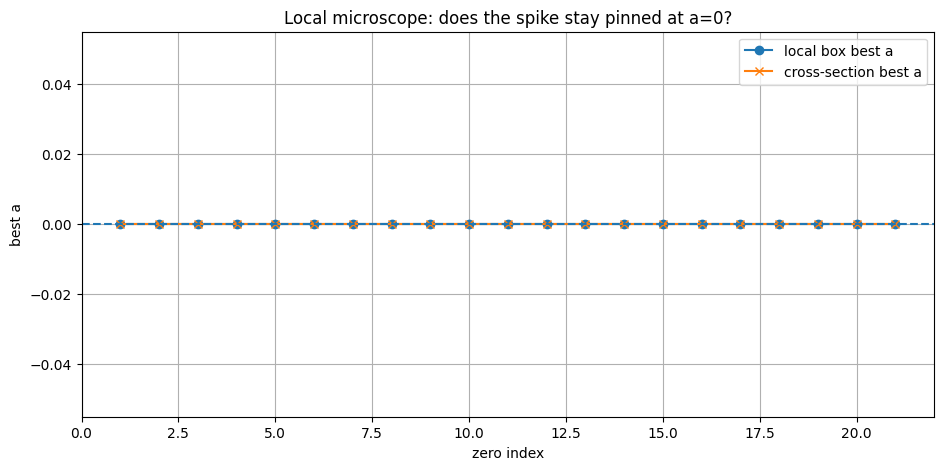

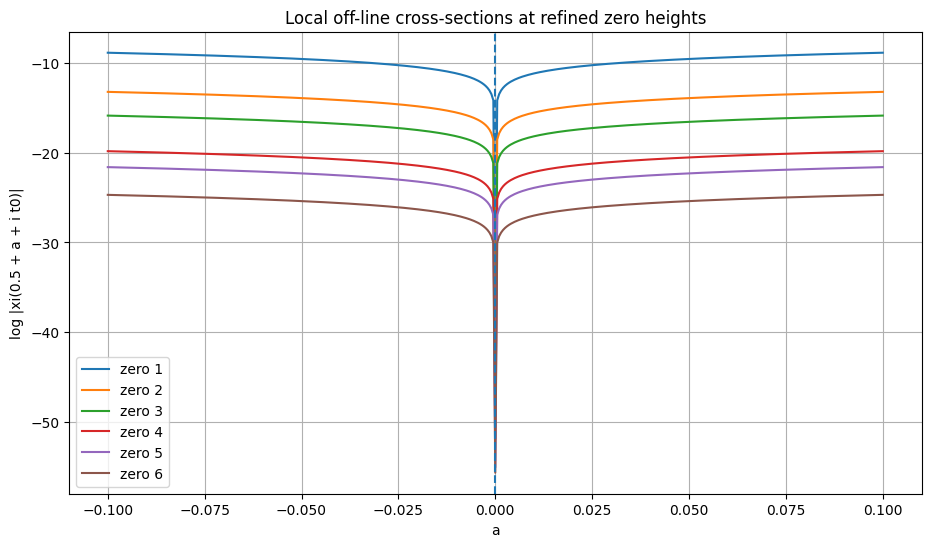

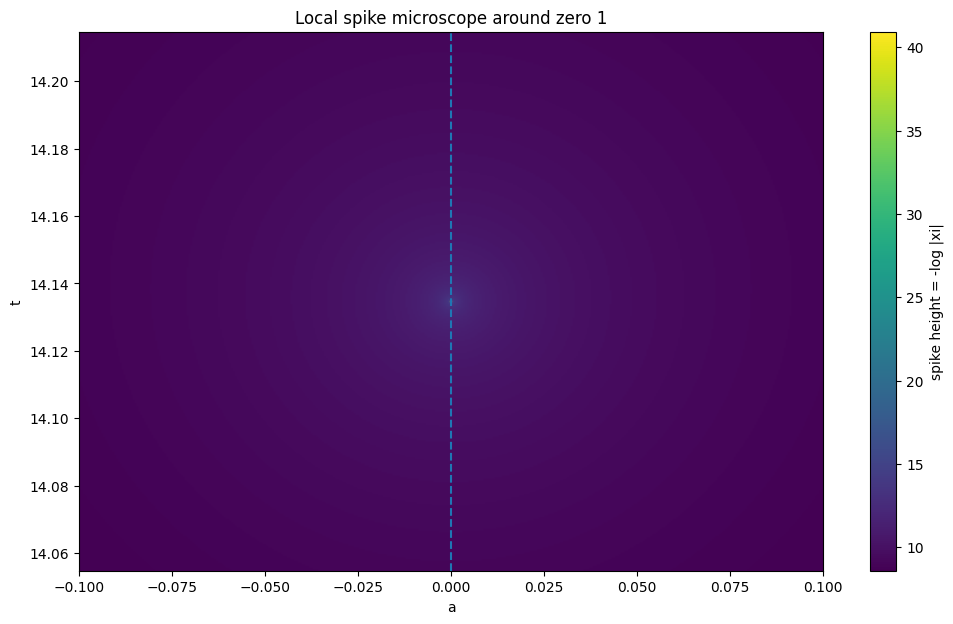


Interpretation guide:

1. If local_box_best_a and cross_section_at_t0_best_a are both 0,
   the detected spike is locally pinned to the critical line.

2. If the off-line ratios are enormous, then tiny movement away from
   a=0 destroys the zero-status/spike.

3. If max_relative_mag_sym_error is tiny, the off-line profile is
   magnitude-symmetric around the critical line.

4. This is still local confirmation, not a proof of RH.
   It verifies that the wide-scan candidates are critical-line spikes,
   then measures how sharply off-line displacement activates a nonzero mode.


In [13]:
# ============================================================
# Continuation cell:
# @title Local microscope around wide-scan zeta spike candidates
#
# Inputs expected from previous wide scan:
#   zeta_wide_offline_candidates.csv
#   zeta_wide_best_a_by_t.csv
#   zeta_wide_center_compare.csv
#
# Purpose:
#   1. Load detected center-line spike candidates.
#   2. Refine their t-locations using zeta zeros.
#   3. Scan small off-line displacements around each refined zero.
#   4. Test whether the local minimum stays pinned at a = 0.
#   5. Estimate off-line curvature near the spike.
#
# Interpretation:
#   spike height = -log |xi|
#   local zero-status = |xi| near 0
#   off-line mode = a != 0 in s = 1/2 + a + i t
# ============================================================

import os
import numpy as np
import pandas as pd
import mpmath as mp
import matplotlib.pyplot as plt

mp.mp.dps = 80

# ----------------------------
# Config
# ----------------------------

CANDIDATE_CSV = "zeta_wide_offline_candidates.csv"

# Local off-line microscope range.
# Keep small: we are checking local pinning, not doing a wide scan.
A_LOCAL_MIN = -0.10
A_LOCAL_MAX =  0.10
A_LOCAL_POINTS = 401

# Local t window around each candidate.
T_LOCAL_HALF_WIDTH = 0.08
T_LOCAL_POINTS = 321

# How many candidates to refine/view.
# None = use all detected candidates.
MAX_CANDIDATES = None

EPS = mp.mpf("1e-100")

OUT_LOCAL_GRID = "zeta_local_spike_microscope_grid.csv"
OUT_LOCAL_SUMMARY = "zeta_local_spike_microscope_summary.csv"

# ----------------------------
# Completed zeta / xi
# ----------------------------

def xi(s):
    """
    Riemann xi function:
        xi(s) = 1/2 * s * (s-1) * pi^(-s/2) * Gamma(s/2) * zeta(s)

    Symmetry:
        xi(s) = xi(1-s)
    """
    return (
        mp.mpf("0.5")
        * s
        * (s - 1)
        * mp.power(mp.pi, -s / 2)
        * mp.gamma(s / 2)
        * mp.zeta(s)
    )

def log_abs_xi_at(a, t):
    s = mp.mpc(mp.mpf("0.5") + mp.mpf(str(a)), mp.mpf(str(t)))
    return float(mp.log(abs(xi(s)) + EPS))

def abs_xi_at(a, t):
    s = mp.mpc(mp.mpf("0.5") + mp.mpf(str(a)), mp.mpf(str(t)))
    return float(abs(xi(s)))

# ----------------------------
# Load candidates
# ----------------------------

if not os.path.exists(CANDIDATE_CSV):
    raise FileNotFoundError(
        f"Could not find {CANDIDATE_CSV}. "
        "Run the wide off-line scan first, or place the candidate CSV in this directory."
    )

cand = pd.read_csv(CANDIDATE_CSV)

if len(cand) == 0:
    raise ValueError("Candidate CSV exists but contains no candidates.")

# Keep unique candidate t values.
# Wide scan used coarse t grid, so these are approximate.
cand = cand.sort_values("log_abs_xi").reset_index(drop=True)

if MAX_CANDIDATES is not None:
    cand = cand.head(MAX_CANDIDATES)

approx_t_values = sorted(cand["t"].unique())

print(f"Loaded {len(cand)} candidate rows.")
print(f"Unique candidate t-values: {len(approx_t_values)}")
print(approx_t_values)

# ----------------------------
# Match each approximate t to nearest known zeta zero
# ----------------------------

def nearest_zeta_zero_height(t_approx, search_n_max=200):
    """
    Find the known critical-line zeta zero height closest to t_approx.

    For t up to ~80, n<=30 is enough, but search_n_max=200 is still fine.
    """
    best_n = None
    best_t = None
    best_dist = float("inf")

    for n in range(1, search_n_max + 1):
        z = mp.zetazero(n)
        t = float(mp.im(z))
        dist = abs(t - t_approx)

        if dist < best_dist:
            best_dist = dist
            best_n = n
            best_t = t

        # stop once zeros are well beyond the candidate
        if t > t_approx + 10:
            break

    return best_n, best_t, best_dist

matched = []

for t_approx in approx_t_values:
    n, t_refined, dist = nearest_zeta_zero_height(t_approx)

    matched.append({
        "candidate_t_grid": float(t_approx),
        "nearest_zero_index": int(n),
        "refined_zero_t": float(t_refined),
        "grid_to_refined_distance": float(dist),
    })

matched_df = pd.DataFrame(matched)

print()
print("Matched candidates to known critical-line zeros:")
display(matched_df)

# ----------------------------
# Local microscope scan
# ----------------------------

a_values = np.linspace(A_LOCAL_MIN, A_LOCAL_MAX, A_LOCAL_POINTS)

local_rows = []
summary_rows = []

for _, row in matched_df.iterrows():
    zero_index = int(row["nearest_zero_index"])
    t0 = float(row["refined_zero_t"])

    print(f"Scanning local microscope around zero {zero_index}, t={t0:.12f}")

    t_values = np.linspace(
        t0 - T_LOCAL_HALF_WIDTH,
        t0 + T_LOCAL_HALF_WIDTH,
        T_LOCAL_POINTS
    )

    Z = np.empty((T_LOCAL_POINTS, A_LOCAL_POINTS), dtype=float)

    for i, t in enumerate(t_values):
        for j, a in enumerate(a_values):
            Z[i, j] = log_abs_xi_at(a, t)

    # Global local minimum in the microscope box
    min_idx = np.unravel_index(np.argmin(Z), Z.shape)
    i_min, j_min = min_idx

    best_t = float(t_values[i_min])
    best_a = float(a_values[j_min])
    best_sigma = float(0.5 + best_a)
    best_log_abs = float(Z[i_min, j_min])

    # Center-line minimum in the same t window
    j_center = int(np.argmin(np.abs(a_values)))
    center_col = Z[:, j_center]
    i_center_min = int(np.argmin(center_col))

    center_best_t = float(t_values[i_center_min])
    center_best_a = float(a_values[j_center])
    center_best_log_abs = float(center_col[i_center_min])

    # Cross-section at refined zero height
    i_t0 = int(np.argmin(np.abs(t_values - t0)))
    cross = Z[i_t0, :]

    j_cross_min = int(np.argmin(cross))
    cross_best_a = float(a_values[j_cross_min])
    cross_best_log_abs = float(cross[j_cross_min])

    # Curvature estimate in a-direction at a=0, t=t0:
    # Use finite differences on log|xi| around center.
    # Since log|xi| is singular at the exact zero, curvature on log scale can be unstable.
    # We also estimate curvature of |xi| using nearby values.
    center_j = j_center

    if 1 <= center_j < A_LOCAL_POINTS - 1:
        da = float(a_values[center_j + 1] - a_values[center_j])
        f_minus = float(cross[center_j - 1])
        f_center = float(cross[center_j])
        f_plus = float(cross[center_j + 1])
        log_curvature_a = (f_plus - 2*f_center + f_minus) / (da ** 2)
    else:
        log_curvature_a = np.nan

    # Use a fixed small offsets to measure spike destruction
    offsets_to_check = [0.0025, 0.005, 0.01, 0.02, 0.05, 0.10]
    offset_metrics = {}

    center_abs = abs_xi_at(0.0, t0)

    for off in offsets_to_check:
        pos_abs = abs_xi_at(off, t0)
        neg_abs = abs_xi_at(-off, t0)

        offset_metrics[f"abs_xi_a_plus_{off}"] = pos_abs
        offset_metrics[f"abs_xi_a_minus_{off}"] = neg_abs
        offset_metrics[f"ratio_plus_{off}_to_center"] = pos_abs / (center_abs + float(EPS))
        offset_metrics[f"ratio_minus_{off}_to_center"] = neg_abs / (center_abs + float(EPS))

    # Symmetric magnitude check at refined zero height
    sym_errors = []
    for a in a_values:
        plus = abs_xi_at(a, t0)
        minus = abs_xi_at(-a, t0)
        denom = max(plus, minus, 1e-300)
        sym_errors.append(abs(plus - minus) / denom)

    max_relative_mag_sym_error = float(np.max(sym_errors))

    summary_rows.append({
        "zero_index": zero_index,
        "candidate_t_grid": float(row["candidate_t_grid"]),
        "refined_zero_t": t0,
        "grid_to_refined_distance": float(row["grid_to_refined_distance"]),

        "local_box_best_a": best_a,
        "local_box_best_sigma": best_sigma,
        "local_box_best_t": best_t,
        "local_box_best_log_abs_xi": best_log_abs,

        "centerline_best_t": center_best_t,
        "centerline_best_a": center_best_a,
        "centerline_best_log_abs_xi": center_best_log_abs,

        "cross_section_at_t0_best_a": cross_best_a,
        "cross_section_at_t0_best_log_abs_xi": cross_best_log_abs,

        "abs_xi_at_center_t0": center_abs,
        "log_curvature_a_near_center": float(log_curvature_a),
        "max_relative_mag_sym_error": max_relative_mag_sym_error,

        **offset_metrics,
    })

    # Store local grid in long form
    for i, t in enumerate(t_values):
        for j, a in enumerate(a_values):
            local_rows.append({
                "zero_index": zero_index,
                "refined_zero_t": t0,
                "t": float(t),
                "a": float(a),
                "sigma": float(0.5 + a),
                "log_abs_xi": float(Z[i, j]),
                "spike_height": float(-Z[i, j]),
            })

local_grid = pd.DataFrame(local_rows)
summary = pd.DataFrame(summary_rows)

local_grid.to_csv(OUT_LOCAL_GRID, index=False)
summary.to_csv(OUT_LOCAL_SUMMARY, index=False)

print()
print(f"Saved local microscope grid -> {OUT_LOCAL_GRID}")
print(f"Saved local microscope summary -> {OUT_LOCAL_SUMMARY}")

print()
print("Local microscope summary:")
display(summary)

# ----------------------------
# Main checks
# ----------------------------

print()
print("Main pinning checks:")

print("Max |local_box_best_a|:")
print(summary["local_box_best_a"].abs().max())

print()
print("Max |cross_section_at_t0_best_a|:")
print(summary["cross_section_at_t0_best_a"].abs().max())

print()
print("Worst relative magnitude symmetry error:")
print(summary["max_relative_mag_sym_error"].max())

# ----------------------------
# Plot 1:
# best a in each local box
# ----------------------------

plt.figure(figsize=(11, 5))
plt.plot(summary["zero_index"], summary["local_box_best_a"], marker="o", label="local box best a")
plt.plot(summary["zero_index"], summary["cross_section_at_t0_best_a"], marker="x", label="cross-section best a")
plt.axhline(0, linestyle="--")
plt.xlabel("zero index")
plt.ylabel("best a")
plt.title("Local microscope: does the spike stay pinned at a=0?")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 2:
# local cross-sections for selected zeros
# ----------------------------

selected_zero_indices = list(summary["zero_index"].head(6))

plt.figure(figsize=(11, 6))

for zero_index in selected_zero_indices:
    t0 = float(summary.loc[summary["zero_index"] == zero_index, "refined_zero_t"].iloc[0])

    sub = local_grid[local_grid["zero_index"] == zero_index].copy()
    # choose row closest to refined t0
    t_closest = sub.iloc[(sub["t"] - t0).abs().argmin()]["t"]
    cross = sub[sub["t"] == t_closest].sort_values("a")

    plt.plot(cross["a"], cross["log_abs_xi"], label=f"zero {zero_index}")

plt.axvline(0, linestyle="--")
plt.xlabel("a")
plt.ylabel("log |xi(0.5 + a + i t0)|")
plt.title("Local off-line cross-sections at refined zero heights")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 3:
# heatmap around first candidate
# ----------------------------

first_zero = int(summary["zero_index"].iloc[0])
sub = local_grid[local_grid["zero_index"] == first_zero].copy()

pivot = sub.pivot(index="t", columns="a", values="spike_height")
t_axis = pivot.index.values
a_axis = pivot.columns.values
M = pivot.values

plt.figure(figsize=(12, 7))
plt.imshow(
    M,
    extent=[a_axis.min(), a_axis.max(), t_axis.min(), t_axis.max()],
    origin="lower",
    aspect="auto",
)
plt.colorbar(label="spike height = -log |xi|")
plt.axvline(0, linestyle="--")
plt.xlabel("a")
plt.ylabel("t")
plt.title(f"Local spike microscope around zero {first_zero}")
plt.show()

# ----------------------------
# Interpretation guide
# ----------------------------

print()
print("Interpretation guide:")
print()
print("1. If local_box_best_a and cross_section_at_t0_best_a are both 0,")
print("   the detected spike is locally pinned to the critical line.")
print()
print("2. If the off-line ratios are enormous, then tiny movement away from")
print("   a=0 destroys the zero-status/spike.")
print()
print("3. If max_relative_mag_sym_error is tiny, the off-line profile is")
print("   magnitude-symmetric around the critical line.")
print()
print("4. This is still local confirmation, not a proof of RH.")
print("   It verifies that the wide-scan candidates are critical-line spikes,")
print("   then measures how sharply off-line displacement activates a nonzero mode.")

Center band excluded: |a| < 0.01
Off-line a-points kept: 236 / 241
t-points: 1201
Total scan points: 283,436
  row 0/1201  t=0.0000
  row 50/1201  t=3.3333
  row 100/1201  t=6.6667
  row 150/1201  t=10.0000
  row 200/1201  t=13.3333
  row 250/1201  t=16.6667
  row 300/1201  t=20.0000
  row 350/1201  t=23.3333
  row 400/1201  t=26.6667
  row 450/1201  t=30.0000
  row 500/1201  t=33.3333
  row 550/1201  t=36.6667
  row 600/1201  t=40.0000
  row 650/1201  t=43.3333
  row 700/1201  t=46.6667
  row 750/1201  t=50.0000
  row 800/1201  t=53.3333
  row 850/1201  t=56.6667
  row 900/1201  t=60.0000
  row 950/1201  t=63.3333
  row 1000/1201  t=66.6667
  row 1050/1201  t=70.0000
  row 1100/1201  t=73.3333
  row 1150/1201  t=76.6667
  row 1200/1201  t=80.0000
Scan complete.

Saved full off-line-only scan -> zeta_offline_only_scan_full.csv

Saved off-line candidates -> zeta_offline_only_candidates.csv
Candidate count: 11

Strongest off-line-only candidates:


,t,a,sigma,abs_a,log_abs_xi,spike_height,epsilon_a,kind
0,79.333333,0.01225,0.51225,0.01225,-57.923357,57.923357,0.01,off_line_local_minimum
1,72.066667,0.01225,0.51225,0.01225,-52.317053,52.317053,0.01,off_line_local_minimum
2,65.133333,0.01225,0.51225,0.01225,-46.638583,46.638583,0.01,off_line_local_minimum
3,53.000000,0.01225,0.51225,0.01225,-37.114473,37.114473,0.01,off_line_local_minimum
4,43.333333,0.01225,0.51225,0.01225,-31.003377,31.003377,0.01,off_line_local_minimum
5,40.933333,0.01225,0.51225,0.01225,-29.102174,29.102174,0.01,off_line_local_minimum
6,37.600000,0.01225,0.51225,0.01225,-26.402777,26.402777,0.01,off_line_local_minimum
7,32.933333,0.01225,0.51225,0.01225,-23.706471,23.706471,0.01,off_line_local_minimum
8,25.000000,0.01225,0.51225,0.01225,-17.686270,17.686270,0.01,off_line_local_minimum
9,21.000000,0.01225,0.51225,0.01225,-14.602828,14.602828,0.01,off_line_local_minimum



Saved best off-line a by t -> zeta_offline_only_best_by_t.csv
Strongest best-offline rows:


,t,best_offline_a,best_offline_sigma,best_offline_abs_a,best_offline_log_abs_xi,best_offline_spike_height,epsilon_a
1190,79.333333,0.01225,0.51225,0.01225,-57.923357,57.923357,0.01
1157,77.133333,-0.01225,0.48775,0.01225,-56.575483,56.575483,0.01
1191,79.400000,-0.01225,0.48775,0.01225,-56.353529,56.353529,0.01
1189,79.266667,-0.01225,0.48775,0.01225,-56.180612,56.180612,0.01
1192,79.466667,-0.01225,0.48775,0.01225,-55.674134,55.674134,0.01
1188,79.200000,-0.01225,0.48775,0.01225,-55.503093,55.503093,0.01
1158,77.200000,-0.01225,0.48775,0.01225,-55.394683,55.394683,0.01
1193,79.533333,-0.01225,0.48775,0.01225,-55.294270,55.294270,0.01
1187,79.133333,-0.01225,0.48775,0.01225,-55.087904,55.087904,0.01
1194,79.600000,-0.01225,0.48775,0.01225,-55.037962,55.037962,0.01



Saved off-line vs center comparison -> zeta_offline_only_center_compare.csv

Rows where off-line beats center at same t:


,t,center_a,center_sigma,center_log_abs_xi,center_spike_height,best_offline_a,best_offline_sigma,best_offline_abs_a,best_offline_log_abs_xi,best_offline_spike_height,offline_minus_center_log,offline_to_center_abs_ratio,epsilon_a



Strongest center-line spikes and their best off-line shoulders:


,t,center_a,center_sigma,center_log_abs_xi,center_spike_height,best_offline_a,best_offline_sigma,best_offline_abs_a,best_offline_log_abs_xi,best_offline_spike_height,offline_minus_center_log,offline_to_center_abs_ratio,epsilon_a
1190,79.333333,0.0,0.5,-59.083925,59.083925,0.01225,0.51225,0.01225,-57.923357,57.923357,1.160568,3.191745,0.01
1157,77.133333,0.0,0.5,-56.954399,56.954399,-0.01225,0.48775,0.01225,-56.575483,56.575483,0.378916,1.460700,0.01
1191,79.400000,0.0,0.5,-56.372342,56.372342,-0.01225,0.48775,0.01225,-56.353529,56.353529,0.018813,1.018991,0.01
1189,79.266667,0.0,0.5,-56.195439,56.195439,-0.01225,0.48775,0.01225,-56.180612,56.180612,0.014827,1.014937,0.01
1192,79.466667,0.0,0.5,-55.678641,55.678641,-0.01225,0.48775,0.01225,-55.674134,55.674134,0.004506,1.004516,0.01
1081,72.066667,0.0,0.5,-55.534709,55.534709,0.01225,0.51225,0.01225,-52.317053,52.317053,3.217657,24.969536,0.01
1188,79.200000,0.0,0.5,-55.507095,55.507095,-0.01225,0.48775,0.01225,-55.503093,55.503093,0.004002,1.004010,0.01
1158,77.200000,0.0,0.5,-55.418818,55.418818,-0.01225,0.48775,0.01225,-55.394683,55.394683,0.024136,1.024429,0.01
1193,79.533333,0.0,0.5,-55.296257,55.296257,-0.01225,0.48775,0.01225,-55.294270,55.294270,0.001987,1.001989,0.01
1187,79.133333,0.0,0.5,-55.089746,55.089746,-0.01225,0.48775,0.01225,-55.087904,55.087904,0.001842,1.001843,0.01


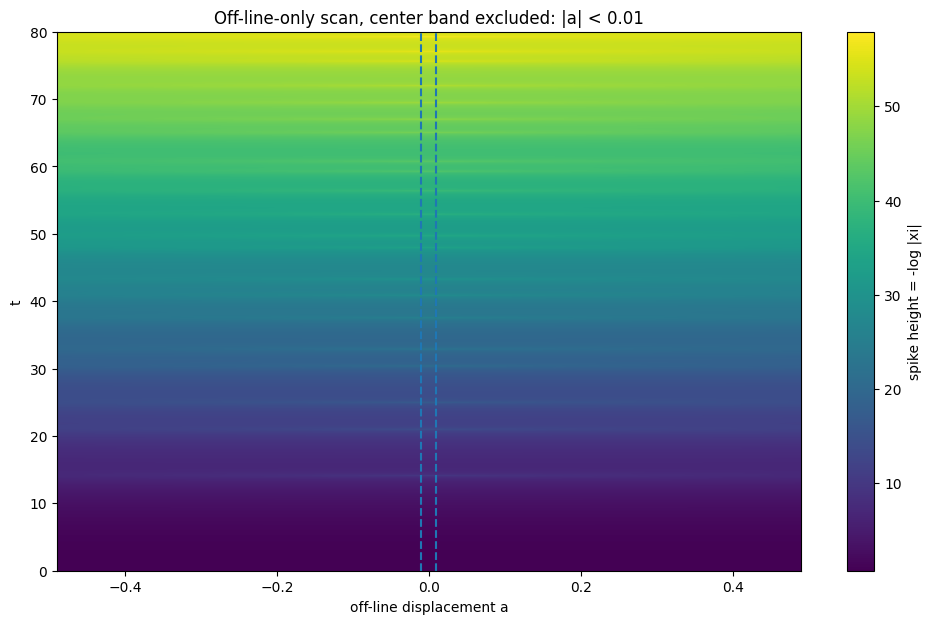

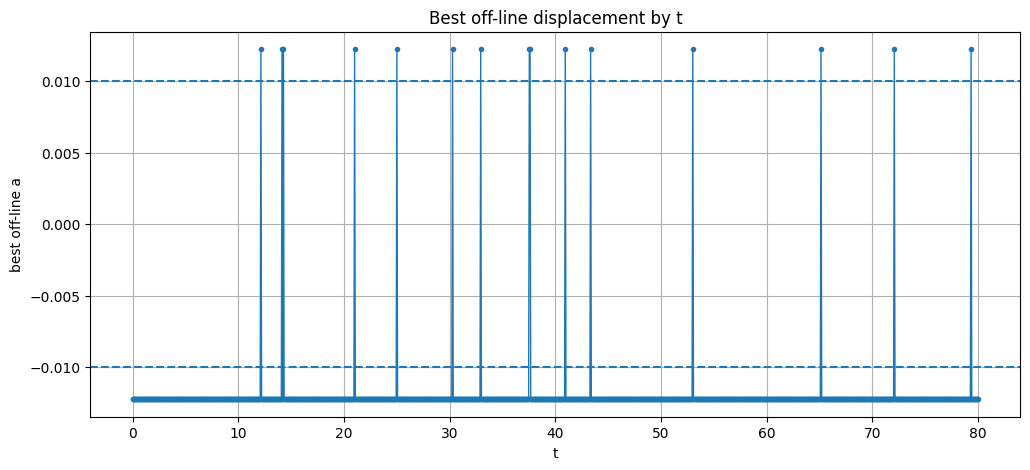

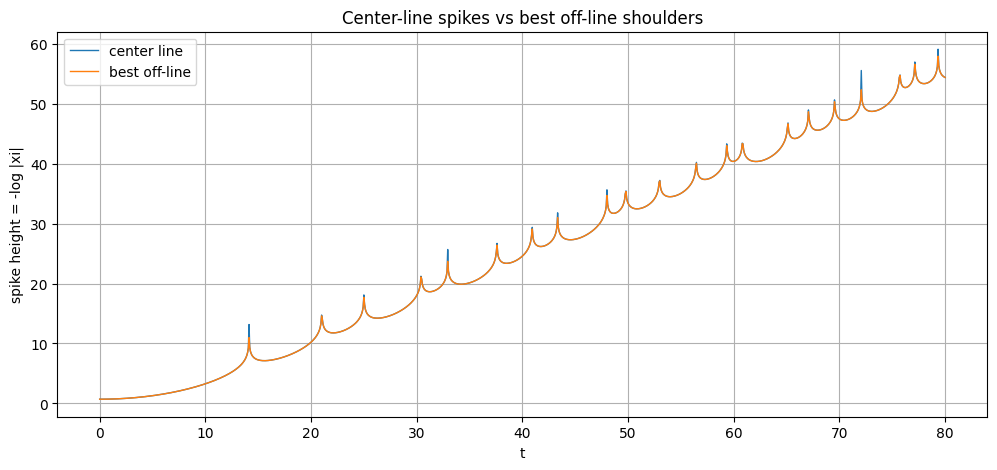

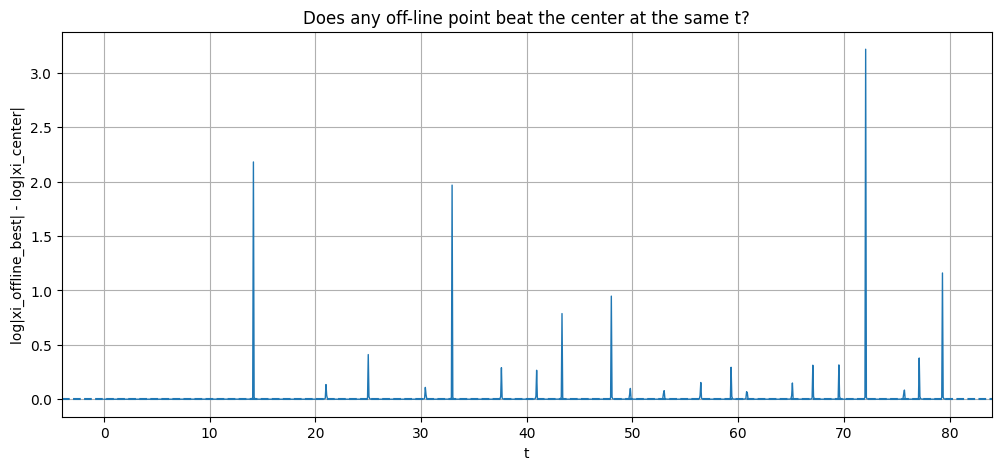

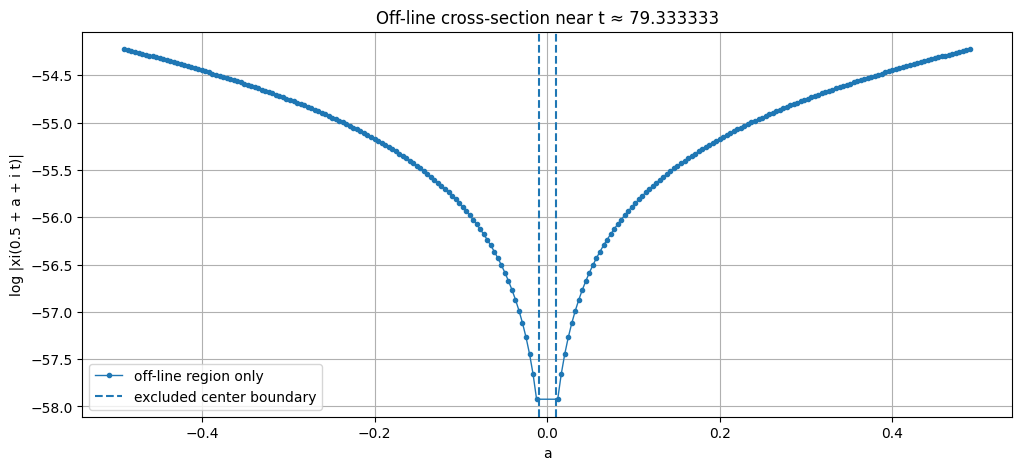


Final summary:
Excluded center band: |a| < 0.01
Candidate threshold: log|xi| < -4.0
Off-line candidate count: 11

Strongest off-line local minimum:
t                            79.333333
a                              0.01225
sigma                          0.51225
abs_a                          0.01225
log_abs_xi                  -57.923357
spike_height                 57.923357
epsilon_a                         0.01
kind            off_line_local_minimum

Minimum off-line-minus-center log difference:
3.467192610795422e-06
No off-line point beat the center at the same t in this scan.

Interpretation guide:
1. If off-line candidates exist but sit close to ±EPSILON_A,
   they may be shoulders of center-line spikes, not independent valleys.
2. A serious off-line candidate should be a true local minimum away from
   the excluded band, stable under finer grids and higher precision.
3. If no such candidates appear, the scan supports the center-only
   spike-status picture over this finite r

In [14]:
# ============================================================
# Continuation cell:
# Off-line-only valley scan for completed zeta xi(s)
#
# Purpose:
#   @title Previous scans showed the strongest spikes/minima occur at a = 0.
#   This scan deliberately masks out the center band |a| < EPSILON_A
#   and asks:
#
#       If the critical line is forbidden, do any serious off-line
#       valleys remain?
#
# Coordinate:
#   s = 1/2 + a + i t
#
# Critical line:
#   a = 0
#
# Off-line-only region:
#   |a| >= EPSILON_A
#
# Interpretation:
#   valley in log|xi|  <=>  spike in -log|xi|
#   off-line candidate <=> deep local minimum with a != 0
#
# This is not a proof of RH.
# It is a numerical search for off-line candidate valleys.
# ============================================================

import os
import numpy as np
import pandas as pd
import mpmath as mp
import matplotlib.pyplot as plt

mp.mp.dps = 60

# ----------------------------
# Config
# ----------------------------

# Scan range in t.
# Start with the same range as the wide scan.
T_MIN = 0.0
T_MAX = 80.0
T_POINTS = 1201

# Off-line displacement range.
# sigma = 0.5 + a must stay inside 0 < sigma < 1.
A_MIN = -0.49
A_MAX =  0.49
A_POINTS = 241

# Exclude the center band.
# Try 0.01 first. Then repeat with 0.025 and 0.05 if needed.
EPSILON_A = 0.01

# Candidate threshold.
# Lower log_abs_xi means closer to zero.
# Use a loose threshold first so we can inspect structure.
CANDIDATE_LOG_THRESHOLD = -4.0

# Local-minimum rule.
# If True, only report points lower than their 8 neighboring grid points.
USE_LOCAL_MINIMA = True

# Output files
OUT_FULL = "zeta_offline_only_scan_full.csv"
OUT_CANDIDATES = "zeta_offline_only_candidates.csv"
OUT_BEST_BY_T = "zeta_offline_only_best_by_t.csv"
OUT_CENTER_COMPARE = "zeta_offline_only_center_compare.csv"

EPS_LOG = mp.mpf("1e-100")

# ----------------------------
# Completed zeta / xi
# ----------------------------

def xi(s):
    """
    Riemann xi function:
        xi(s) = 1/2 * s * (s-1) * pi^(-s/2) * Gamma(s/2) * zeta(s)

    Symmetry:
        xi(s) = xi(1-s)
    """
    return (
        mp.mpf("0.5")
        * s
        * (s - 1)
        * mp.power(mp.pi, -s / 2)
        * mp.gamma(s / 2)
        * mp.zeta(s)
    )

def log_abs_xi(a, t):
    s = mp.mpc(mp.mpf("0.5") + mp.mpf(str(a)), mp.mpf(str(t)))
    return float(mp.log(abs(xi(s)) + EPS_LOG))

# ----------------------------
# Build off-line grid
# ----------------------------

a_all = np.linspace(A_MIN, A_MAX, A_POINTS)

# Mask out the center band.
a_values = a_all[np.abs(a_all) >= EPSILON_A]
t_values = np.linspace(T_MIN, T_MAX, T_POINTS)

print(f"Center band excluded: |a| < {EPSILON_A}")
print(f"Off-line a-points kept: {len(a_values)} / {len(a_all)}")
print(f"t-points: {len(t_values)}")
print(f"Total scan points: {len(a_values) * len(t_values):,}")

Z = np.empty((len(t_values), len(a_values)), dtype=float)

# ----------------------------
# Main scan
# ----------------------------

for i, t in enumerate(t_values):
    if i % 50 == 0:
        print(f"  row {i}/{len(t_values)}  t={t:.4f}")

    for j, a in enumerate(a_values):
        Z[i, j] = log_abs_xi(a, t)

print("Scan complete.")

# ----------------------------
# Full table
# ----------------------------

rows = []

for i, t in enumerate(t_values):
    for j, a in enumerate(a_values):
        rows.append({
            "t": float(t),
            "a": float(a),
            "sigma": float(0.5 + a),
            "abs_a": float(abs(a)),
            "log_abs_xi": float(Z[i, j]),
            "spike_height": float(-Z[i, j]),
            "epsilon_a": float(EPSILON_A),
        })

df = pd.DataFrame(rows)
df.to_csv(OUT_FULL, index=False)

print()
print(f"Saved full off-line-only scan -> {OUT_FULL}")

# ----------------------------
# Candidate detection
# ----------------------------

candidates = []

if USE_LOCAL_MINIMA:
    for i in range(1, len(t_values) - 1):
        for j in range(1, len(a_values) - 1):
            center = Z[i, j]

            if center >= CANDIDATE_LOG_THRESHOLD:
                continue

            neighborhood = Z[i-1:i+2, j-1:j+2].copy()
            neighborhood[1, 1] = np.inf

            if center < np.min(neighborhood):
                candidates.append({
                    "t": float(t_values[i]),
                    "a": float(a_values[j]),
                    "sigma": float(0.5 + a_values[j]),
                    "abs_a": float(abs(a_values[j])),
                    "log_abs_xi": float(center),
                    "spike_height": float(-center),
                    "epsilon_a": float(EPSILON_A),
                    "kind": "off_line_local_minimum",
                })
else:
    idxs = np.argwhere(Z < CANDIDATE_LOG_THRESHOLD)

    for i, j in idxs:
        candidates.append({
            "t": float(t_values[i]),
            "a": float(a_values[j]),
            "sigma": float(0.5 + a_values[j]),
            "abs_a": float(abs(a_values[j])),
            "log_abs_xi": float(Z[i, j]),
            "spike_height": float(-Z[i, j]),
            "epsilon_a": float(EPSILON_A),
            "kind": "off_line_threshold",
        })

cand = pd.DataFrame(candidates)

if len(cand) > 0:
    cand = cand.sort_values("log_abs_xi").reset_index(drop=True)
else:
    cand = pd.DataFrame(columns=[
        "t", "a", "sigma", "abs_a", "log_abs_xi",
        "spike_height", "epsilon_a", "kind"
    ])

cand.to_csv(OUT_CANDIDATES, index=False)

print()
print(f"Saved off-line candidates -> {OUT_CANDIDATES}")
print(f"Candidate count: {len(cand)}")

if len(cand) > 0:
    print()
    print("Strongest off-line-only candidates:")
    display(cand.head(30))
else:
    print("No off-line local minima below threshold.")

# ----------------------------
# Best off-line a for each t
# ----------------------------

best_rows = []

for i, t in enumerate(t_values):
    j_min = int(np.argmin(Z[i, :]))

    best_rows.append({
        "t": float(t),
        "best_offline_a": float(a_values[j_min]),
        "best_offline_sigma": float(0.5 + a_values[j_min]),
        "best_offline_abs_a": float(abs(a_values[j_min])),
        "best_offline_log_abs_xi": float(Z[i, j_min]),
        "best_offline_spike_height": float(-Z[i, j_min]),
        "epsilon_a": float(EPSILON_A),
    })

best_by_t = pd.DataFrame(best_rows)
best_by_t.to_csv(OUT_BEST_BY_T, index=False)

print()
print(f"Saved best off-line a by t -> {OUT_BEST_BY_T}")
print("Strongest best-offline rows:")
display(best_by_t.sort_values("best_offline_log_abs_xi").head(30))

# ----------------------------
# Compare off-line best against center line at same t
# ----------------------------

center_rows = []

for i, t in enumerate(t_values):
    center_log = log_abs_xi(0.0, t)

    j_min = int(np.argmin(Z[i, :]))
    off_log = float(Z[i, j_min])
    off_a = float(a_values[j_min])

    center_rows.append({
        "t": float(t),
        "center_a": 0.0,
        "center_sigma": 0.5,
        "center_log_abs_xi": float(center_log),
        "center_spike_height": float(-center_log),

        "best_offline_a": off_a,
        "best_offline_sigma": float(0.5 + off_a),
        "best_offline_abs_a": float(abs(off_a)),
        "best_offline_log_abs_xi": off_log,
        "best_offline_spike_height": float(-off_log),

        # Positive means off-line is larger/worse than center.
        # Negative means off-line beats center.
        "offline_minus_center_log": float(off_log - center_log),

        # Ratio |xi_offline| / |xi_center|.
        # If > 1, off-line is worse/larger.
        "offline_to_center_abs_ratio": float(np.exp(np.clip(off_log - center_log, -700, 700))),

        "epsilon_a": float(EPSILON_A),
    })

center_compare = pd.DataFrame(center_rows)
center_compare.to_csv(OUT_CENTER_COMPARE, index=False)

print()
print(f"Saved off-line vs center comparison -> {OUT_CENTER_COMPARE}")

print()
print("Rows where off-line beats center at same t:")
offline_beats = center_compare[center_compare["offline_minus_center_log"] < 0].sort_values(
    "offline_minus_center_log"
)
display(offline_beats.head(30))

print()
print("Strongest center-line spikes and their best off-line shoulders:")
display(center_compare.sort_values("center_log_abs_xi").head(30))

# ----------------------------
# Plot 1:
# Off-line-only spike heatmap
# ----------------------------

plt.figure(figsize=(12, 7))
plt.imshow(
    -Z,
    extent=[a_values.min(), a_values.max(), T_MIN, T_MAX],
    origin="lower",
    aspect="auto",
)
plt.colorbar(label="spike height = -log |xi|")
plt.axvline(-EPSILON_A, linestyle="--")
plt.axvline(EPSILON_A, linestyle="--")
plt.xlabel("off-line displacement a")
plt.ylabel("t")
plt.title(f"Off-line-only scan, center band excluded: |a| < {EPSILON_A}")
plt.show()

# ----------------------------
# Plot 2:
# Best off-line a by t
# ----------------------------

plt.figure(figsize=(12, 5))
plt.plot(best_by_t["t"], best_by_t["best_offline_a"], marker=".", linewidth=1)
plt.axhline(-EPSILON_A, linestyle="--")
plt.axhline(EPSILON_A, linestyle="--")
plt.xlabel("t")
plt.ylabel("best off-line a")
plt.title("Best off-line displacement by t")
plt.grid(True)
plt.show()

# ----------------------------
# Plot 3:
# Center vs best off-line spike height
# ----------------------------

plt.figure(figsize=(12, 5))
plt.plot(center_compare["t"], center_compare["center_spike_height"], linewidth=1, label="center line")
plt.plot(center_compare["t"], center_compare["best_offline_spike_height"], linewidth=1, label="best off-line")
plt.xlabel("t")
plt.ylabel("spike height = -log |xi|")
plt.title("Center-line spikes vs best off-line shoulders")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot 4:
# Difference: off-line minus center
# ----------------------------

plt.figure(figsize=(12, 5))
plt.plot(center_compare["t"], center_compare["offline_minus_center_log"], linewidth=1)
plt.axhline(0, linestyle="--")
plt.xlabel("t")
plt.ylabel("log|xi_offline_best| - log|xi_center|")
plt.title("Does any off-line point beat the center at the same t?")
plt.grid(True)
plt.show()

# ----------------------------
# Optional local cross-section around strongest off-line candidate/shoulder
# ----------------------------

if len(cand) > 0:
    t_star = float(cand.iloc[0]["t"])
else:
    t_star = float(best_by_t.sort_values("best_offline_log_abs_xi").iloc[0]["t"])

i_star = int(np.argmin(np.abs(t_values - t_star)))

plt.figure(figsize=(12, 5))
plt.plot(a_values, Z[i_star, :], marker=".", linewidth=1, label="off-line region only")
plt.axvline(-EPSILON_A, linestyle="--", label="excluded center boundary")
plt.axvline(EPSILON_A, linestyle="--")
plt.xlabel("a")
plt.ylabel("log |xi(0.5 + a + i t)|")
plt.title(f"Off-line cross-section near t ≈ {t_star:.6f}")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Final summary
# ----------------------------

print()
print("Final summary:")
print(f"Excluded center band: |a| < {EPSILON_A}")
print(f"Candidate threshold: log|xi| < {CANDIDATE_LOG_THRESHOLD}")
print(f"Off-line candidate count: {len(cand)}")

if len(cand) > 0:
    strongest = cand.iloc[0]
    print()
    print("Strongest off-line local minimum:")
    print(strongest.to_string())
else:
    print()
    print("No off-line local minimum passed the threshold.")

print()
print("Minimum off-line-minus-center log difference:")
print(center_compare["offline_minus_center_log"].min())

if (center_compare["offline_minus_center_log"] < 0).any():
    print("Some off-line points beat the center at the same t. Inspect/refine those rows.")
else:
    print("No off-line point beat the center at the same t in this scan.")

print()
print("Interpretation guide:")
print("1. If off-line candidates exist but sit close to ±EPSILON_A,")
print("   they may be shoulders of center-line spikes, not independent valleys.")
print("2. A serious off-line candidate should be a true local minimum away from")
print("   the excluded band, stable under finer grids and higher precision.")
print("3. If no such candidates appear, the scan supports the center-only")
print("   spike-status picture over this finite region.")


Running off-line-only scan with excluded center band |a| < 0.025
Tag: eps0250
Off-line a-points kept: 228 / 241
t-points: 1201
Total scan points: 273,828
  row 0/1201  t=0.0000
  row 50/1201  t=3.3333
  row 100/1201  t=6.6667
  row 150/1201  t=10.0000
  row 200/1201  t=13.3333
  row 250/1201  t=16.6667
  row 300/1201  t=20.0000
  row 350/1201  t=23.3333
  row 400/1201  t=26.6667
  row 450/1201  t=30.0000
  row 500/1201  t=33.3333
  row 550/1201  t=36.6667
  row 600/1201  t=40.0000
  row 650/1201  t=43.3333
  row 700/1201  t=46.6667
  row 750/1201  t=50.0000
  row 800/1201  t=53.3333
  row 850/1201  t=56.6667
  row 900/1201  t=60.0000
  row 950/1201  t=63.3333
  row 1000/1201  t=66.6667
  row 1050/1201  t=70.0000
  row 1100/1201  t=73.3333
  row 1150/1201  t=76.6667
  row 1200/1201  t=80.0000
Scan complete.

Saved files for eps0250:
  zeta_offline_only_eps0250_full.csv
  zeta_offline_only_eps0250_candidates.csv
  zeta_offline_only_eps0250_best_by_t.csv
  zeta_offline_only_eps0250_cente

,epsilon_a,tag,t_min,t_max,t_points,a_min,a_max,a_points_total,a_points_kept,candidate_log_threshold,...,best_offline_abs_a_max,full_file,candidates_file,best_by_t_file,center_compare_file,strongest_candidate_t,strongest_candidate_a,strongest_candidate_abs_a,strongest_candidate_log_abs_xi,strongest_candidate_spike_height
0,0.025,eps0250,0.0,80.0,1201,-0.49,0.49,241,228,-4.0,...,0.028583,zeta_offline_only_eps0250_full.csv,zeta_offline_only_eps0250_candidates.csv,zeta_offline_only_eps0250_best_by_t.csv,zeta_offline_only_eps0250_center_compare.csv,75.733333,0.028583,0.028583,-54.443555,54.443555



Strongest candidates:


,t,a,sigma,abs_a,log_abs_xi,spike_height,epsilon_a,kind
0,75.733333,0.028583,0.528583,0.028583,-54.443555,54.443555,0.025,off_line_local_minimum
1,69.533333,0.028583,0.528583,0.028583,-49.754123,49.754123,0.025,off_line_local_minimum
2,60.800000,0.028583,0.528583,0.028583,-43.119750,43.119750,0.025,off_line_local_minimum
3,56.466667,0.028583,0.528583,0.028583,-39.666295,39.666295,0.025,off_line_local_minimum
4,48.000000,0.028583,0.528583,0.028583,-33.898107,33.898107,0.025,off_line_local_minimum
5,37.600000,0.028583,0.528583,0.028583,-25.860902,25.860902,0.025,off_line_local_minimum
6,30.400000,0.028583,0.528583,0.028583,-20.789558,20.789558,0.025,off_line_local_minimum
7,25.000000,0.028583,0.528583,0.028583,-17.061398,17.061398,0.025,off_line_local_minimum
8,14.133333,0.028583,0.528583,0.028583,-10.136616,10.136616,0.025,off_line_local_minimum



Rows where off-line beats center:


,t,center_a,center_sigma,center_log_abs_xi,center_spike_height,best_offline_a,best_offline_sigma,best_offline_abs_a,best_offline_log_abs_xi,best_offline_spike_height,offline_minus_center_log,offline_to_center_abs_ratio,epsilon_a



Strongest center-line spikes and best off-line shoulders:


,t,center_a,center_sigma,center_log_abs_xi,center_spike_height,best_offline_a,best_offline_sigma,best_offline_abs_a,best_offline_log_abs_xi,best_offline_spike_height,offline_minus_center_log,offline_to_center_abs_ratio,epsilon_a
1190,79.333333,0.0,0.5,-59.083925,59.083925,-0.028583,0.471417,0.028583,-57.117650,57.117650,1.966275,7.144012,0.025
1157,77.133333,0.0,0.5,-56.954399,56.954399,-0.028583,0.471417,0.028583,-55.969046,55.969046,0.985353,2.678756,0.025
1191,79.400000,0.0,0.5,-56.372342,56.372342,-0.028583,0.471417,0.028583,-56.277517,56.277517,0.094825,1.099467,0.025
1189,79.266667,0.0,0.5,-56.195439,56.195439,-0.028583,0.471417,0.028583,-56.119541,56.119541,0.075898,1.078853,0.025
1192,79.466667,0.0,0.5,-55.678641,55.678641,-0.028583,0.471417,0.028583,-55.654576,55.654576,0.024065,1.024357,0.025
1081,72.066667,0.0,0.5,-55.534709,55.534709,-0.028583,0.471417,0.028583,-51.470265,51.470265,4.064445,58.232558,0.025
1188,79.200000,0.0,0.5,-55.507095,55.507095,-0.028583,0.471417,0.028583,-55.485678,55.485678,0.021416,1.021647,0.025
1158,77.200000,0.0,0.5,-55.418818,55.418818,0.028583,0.528583,0.028583,-55.299541,55.299541,0.119277,1.126682,0.025
1193,79.533333,0.0,0.5,-55.296257,55.296257,-0.028583,0.471417,0.028583,-55.285528,55.285528,0.010729,1.010787,0.025
1187,79.133333,0.0,0.5,-55.089746,55.089746,-0.028583,0.471417,0.028583,-55.079797,55.079797,0.009949,1.009999,0.025


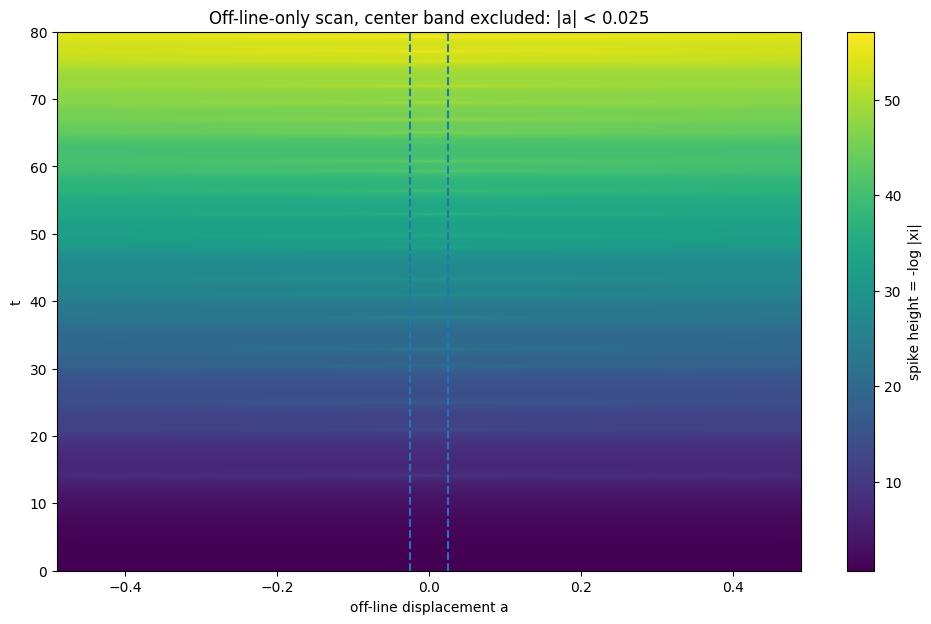

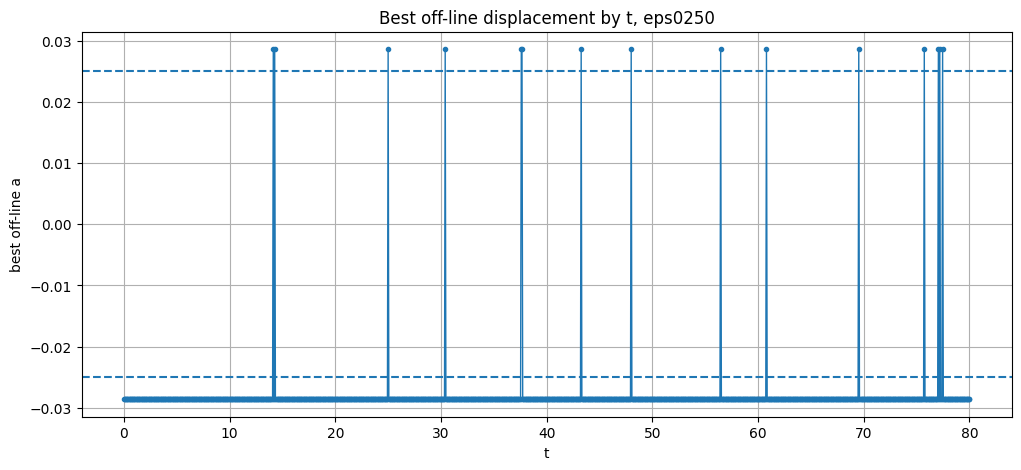

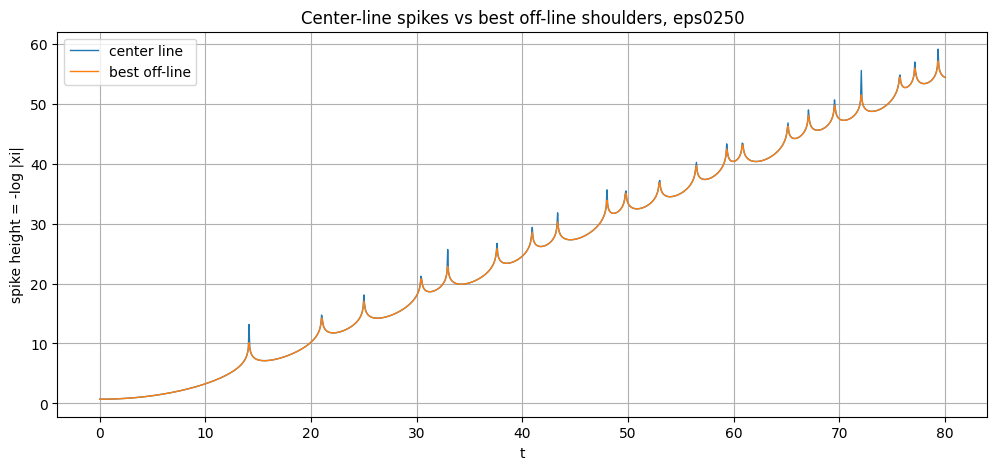

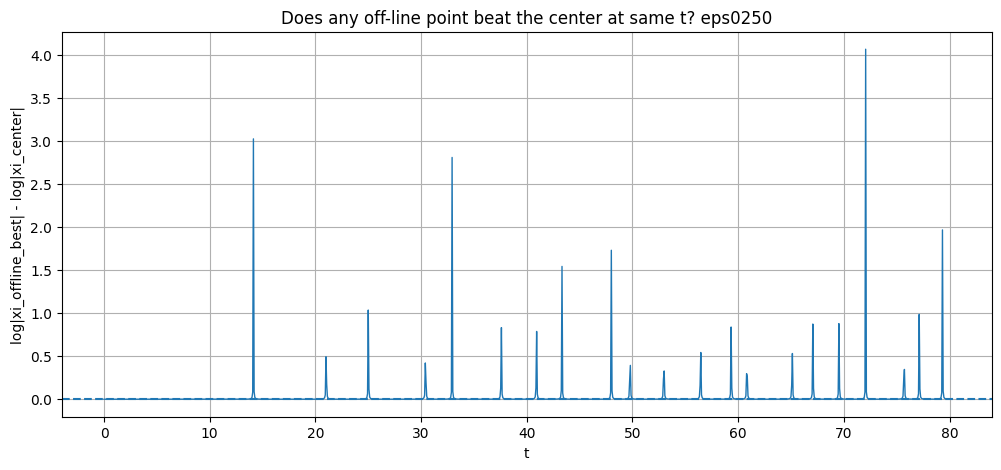


Running off-line-only scan with excluded center band |a| < 0.05
Tag: eps0500
Off-line a-points kept: 216 / 241
t-points: 1201
Total scan points: 259,416
  row 0/1201  t=0.0000
  row 50/1201  t=3.3333
  row 100/1201  t=6.6667
  row 150/1201  t=10.0000
  row 200/1201  t=13.3333
  row 250/1201  t=16.6667
  row 300/1201  t=20.0000
  row 350/1201  t=23.3333
  row 400/1201  t=26.6667
  row 450/1201  t=30.0000
  row 500/1201  t=33.3333
  row 550/1201  t=36.6667
  row 600/1201  t=40.0000
  row 650/1201  t=43.3333
  row 700/1201  t=46.6667
  row 750/1201  t=50.0000
  row 800/1201  t=53.3333
  row 850/1201  t=56.6667
  row 900/1201  t=60.0000
  row 950/1201  t=63.3333
  row 1000/1201  t=66.6667
  row 1050/1201  t=70.0000
  row 1100/1201  t=73.3333
  row 1150/1201  t=76.6667
  row 1200/1201  t=80.0000
Scan complete.

Saved files for eps0500:
  zeta_offline_only_eps0500_full.csv
  zeta_offline_only_eps0500_candidates.csv
  zeta_offline_only_eps0500_best_by_t.csv
  zeta_offline_only_eps0500_center

,epsilon_a,tag,t_min,t_max,t_points,a_min,a_max,a_points_total,a_points_kept,candidate_log_threshold,...,best_offline_abs_a_max,full_file,candidates_file,best_by_t_file,center_compare_file,strongest_candidate_t,strongest_candidate_a,strongest_candidate_abs_a,strongest_candidate_log_abs_xi,strongest_candidate_spike_height
0,0.05,eps0500,0.0,80.0,1201,-0.49,0.49,241,216,-4.0,...,0.053083,zeta_offline_only_eps0500_full.csv,zeta_offline_only_eps0500_candidates.csv,zeta_offline_only_eps0500_best_by_t.csv,zeta_offline_only_eps0500_center_compare.csv,79.333333,0.053083,0.053083,-56.505094,56.505094



Strongest candidates:


,t,a,sigma,abs_a,log_abs_xi,spike_height,epsilon_a,kind
0,79.333333,0.053083,0.553083,0.053083,-56.505094,56.505094,0.05,off_line_local_minimum
1,77.133333,0.053083,0.553083,0.053083,-55.401255,55.401255,0.05,off_line_local_minimum
2,75.733333,0.053083,0.553083,0.053083,-54.043558,54.043558,0.05,off_line_local_minimum
3,67.066667,0.053083,0.553083,0.053083,-47.529149,47.529149,0.05,off_line_local_minimum
4,65.133333,0.053083,0.553083,0.053083,-45.778146,45.778146,0.05,off_line_local_minimum
5,59.333333,0.053083,0.553083,0.053083,-41.908743,41.908743,0.05,off_line_local_minimum
6,43.333333,0.053083,0.553083,0.053083,-29.645682,29.645682,0.05,off_line_local_minimum
7,40.933333,0.053083,0.553083,0.053083,-28.041365,28.041365,0.05,off_line_local_minimum
8,30.400000,0.053083,0.553083,0.053083,-20.352904,20.352904,0.05,off_line_local_minimum
9,25.000000,0.053083,0.553083,0.053083,-16.489094,16.489094,0.05,off_line_local_minimum



Rows where off-line beats center:


,t,center_a,center_sigma,center_log_abs_xi,center_spike_height,best_offline_a,best_offline_sigma,best_offline_abs_a,best_offline_log_abs_xi,best_offline_spike_height,offline_minus_center_log,offline_to_center_abs_ratio,epsilon_a



Strongest center-line spikes and best off-line shoulders:


,t,center_a,center_sigma,center_log_abs_xi,center_spike_height,best_offline_a,best_offline_sigma,best_offline_abs_a,best_offline_log_abs_xi,best_offline_spike_height,offline_minus_center_log,offline_to_center_abs_ratio,epsilon_a
1190,79.333333,0.0,0.5,-59.083925,59.083925,0.053083,0.553083,0.053083,-56.505094,56.505094,2.578831,13.181718,0.05
1157,77.133333,0.0,0.5,-56.954399,56.954399,0.053083,0.553083,0.053083,-55.401255,55.401255,1.553144,4.726305,0.05
1191,79.400000,0.0,0.5,-56.372342,56.372342,-0.053083,0.446917,0.053083,-56.100895,56.100895,0.271448,1.311862,0.05
1189,79.266667,0.0,0.5,-56.195439,56.195439,-0.053083,0.446917,0.053083,-55.971184,55.971184,0.224255,1.251390,0.05
1192,79.466667,0.0,0.5,-55.678641,55.678641,-0.053083,0.446917,0.053083,-55.600040,55.600040,0.078600,1.081772,0.05
1081,72.066667,0.0,0.5,-55.534709,55.534709,-0.053083,0.446917,0.053083,-50.850894,50.850894,4.683815,108.182008,0.05
1188,79.200000,0.0,0.5,-55.507095,55.507095,-0.053083,0.446917,0.053083,-55.436734,55.436734,0.070360,1.072895,0.05
1158,77.200000,0.0,0.5,-55.418818,55.418818,-0.053083,0.446917,0.053083,-55.089851,55.089851,0.328967,1.389532,0.05
1193,79.533333,0.0,0.5,-55.296257,55.296257,-0.053083,0.446917,0.053083,-55.260151,55.260151,0.036106,1.036766,0.05
1187,79.133333,0.0,0.5,-55.089746,55.089746,-0.053083,0.446917,0.053083,-55.056200,55.056200,0.033546,1.034115,0.05


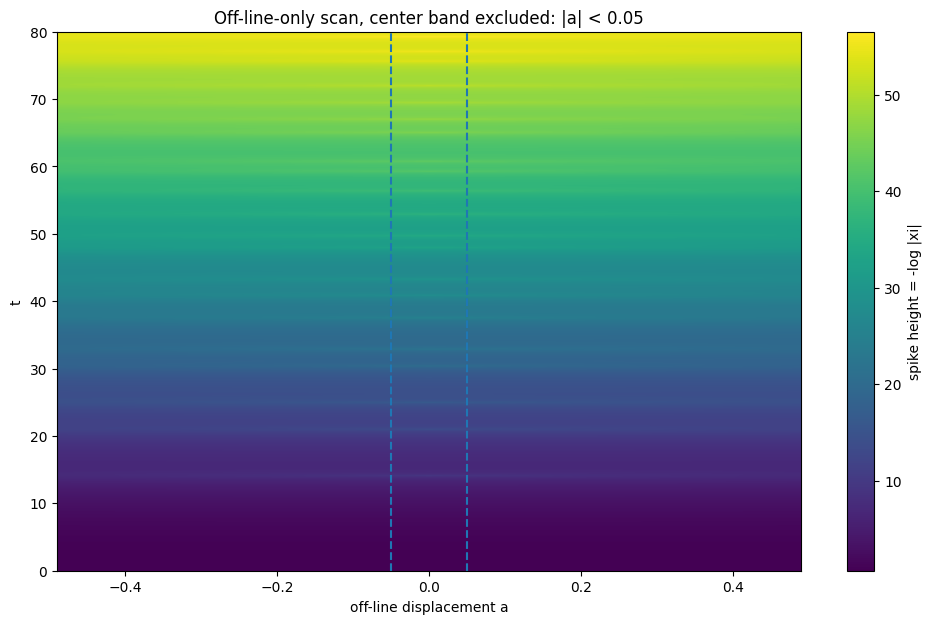

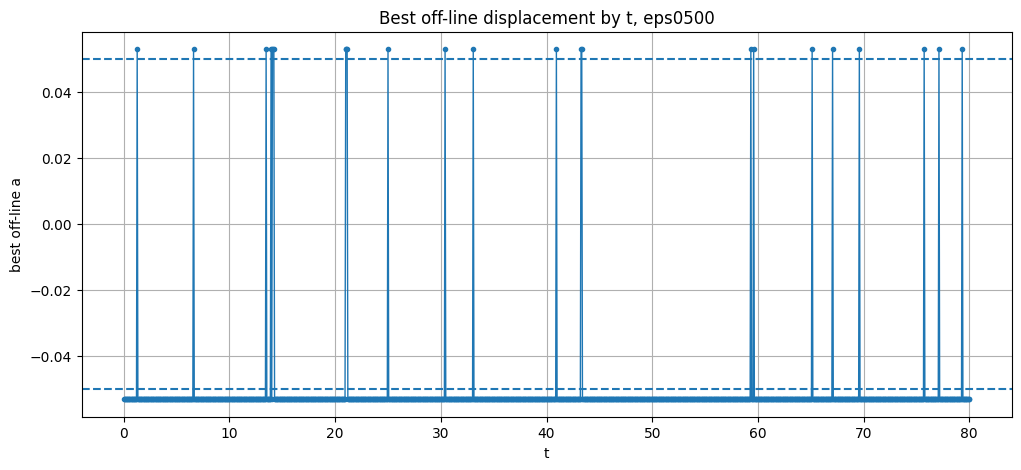

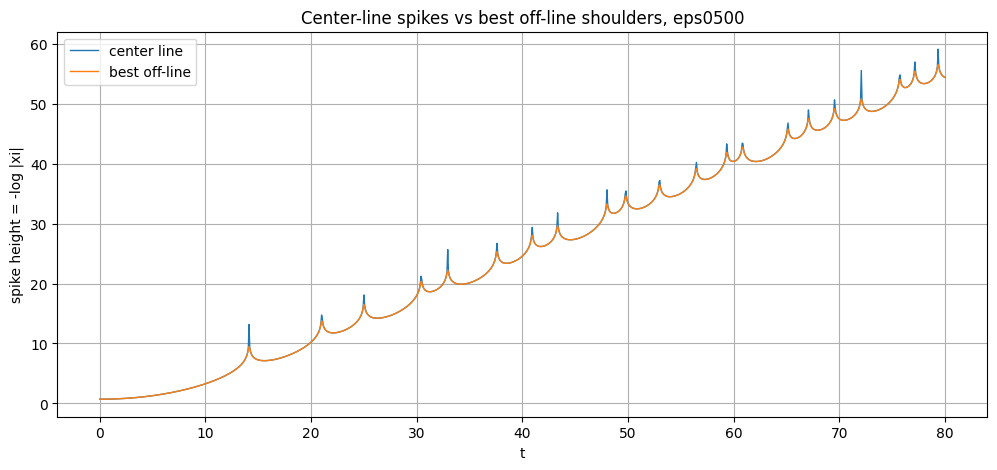

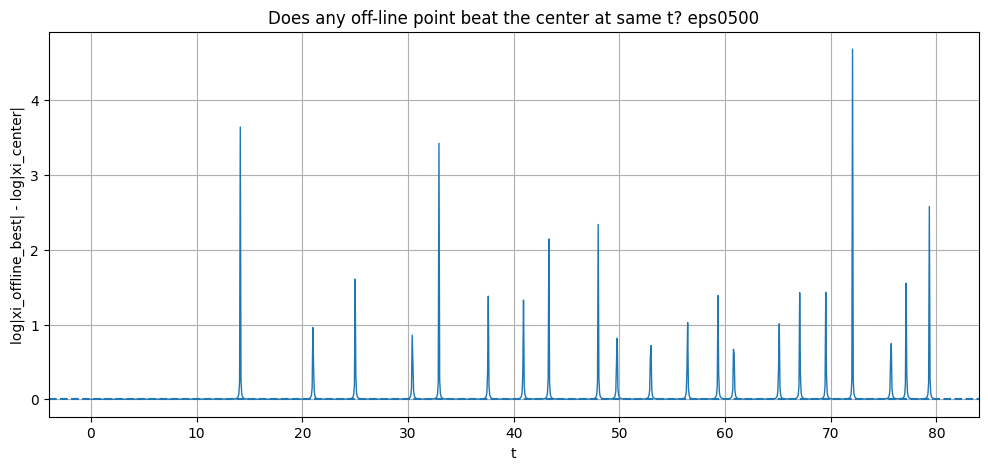


Combined summary:


,epsilon_a,tag,t_min,t_max,t_points,a_min,a_max,a_points_total,a_points_kept,candidate_log_threshold,...,best_offline_abs_a_max,full_file,candidates_file,best_by_t_file,center_compare_file,strongest_candidate_t,strongest_candidate_a,strongest_candidate_abs_a,strongest_candidate_log_abs_xi,strongest_candidate_spike_height
0,0.025,eps0250,0.0,80.0,1201,-0.49,0.49,241,228,-4.0,...,0.028583,zeta_offline_only_eps0250_full.csv,zeta_offline_only_eps0250_candidates.csv,zeta_offline_only_eps0250_best_by_t.csv,zeta_offline_only_eps0250_center_compare.csv,75.733333,0.028583,0.028583,-54.443555,54.443555
1,0.050,eps0500,0.0,80.0,1201,-0.49,0.49,241,216,-4.0,...,0.053083,zeta_offline_only_eps0500_full.csv,zeta_offline_only_eps0500_candidates.csv,zeta_offline_only_eps0500_best_by_t.csv,zeta_offline_only_eps0500_center_compare.csv,79.333333,0.053083,0.053083,-56.505094,56.505094


Saved -> zeta_offline_only_wider_masks_combined_summary.csv


In [15]:
# ============================================================
# Continuation cell:
# @title Off-line-only valley scan at wider exclusion bands
#
# Purpose:
#   Repeat the off-line-only scan with larger excluded center bands:
#
#       |a| < 0.025
#       |a| < 0.05
#
#   This tests whether previous off-line candidates were merely
#   shoulders of the central spike at the exclusion boundary.
#
# Output files are named with the epsilon value, e.g.
#   zeta_offline_only_eps0025_candidates.csv
#   zeta_offline_only_eps0050_candidates.csv
#
# This keeps the previous eps0010 files intact.
# ============================================================

import os
import numpy as np
import pandas as pd
import mpmath as mp
import matplotlib.pyplot as plt

mp.mp.dps = 60

# ----------------------------
# Config
# ----------------------------

T_MIN = 0.0
T_MAX = 80.0
T_POINTS = 1201

A_MIN = -0.49
A_MAX =  0.49
A_POINTS = 241

# Run both wider masks.
EPSILON_A_VALUES = [0.025, 0.05]

CANDIDATE_LOG_THRESHOLD = -4.0
USE_LOCAL_MINIMA = True

EPS_LOG = mp.mpf("1e-100")

# ----------------------------
# Completed zeta / xi
# ----------------------------

def xi(s):
    return (
        mp.mpf("0.5")
        * s
        * (s - 1)
        * mp.power(mp.pi, -s / 2)
        * mp.gamma(s / 2)
        * mp.zeta(s)
    )

def log_abs_xi(a, t):
    s = mp.mpc(mp.mpf("0.5") + mp.mpf(str(a)), mp.mpf(str(t)))
    return float(mp.log(abs(xi(s)) + EPS_LOG))

def eps_tag(eps):
    """
    0.025 -> eps0025
    0.05  -> eps0050
    """
    return f"eps{int(round(eps * 10000)):04d}"

# ----------------------------
# Main reusable scanner
# ----------------------------

def run_offline_only_scan(EPSILON_A):
    tag = eps_tag(EPSILON_A)

    OUT_FULL = f"zeta_offline_only_{tag}_full.csv"
    OUT_CANDIDATES = f"zeta_offline_only_{tag}_candidates.csv"
    OUT_BEST_BY_T = f"zeta_offline_only_{tag}_best_by_t.csv"
    OUT_CENTER_COMPARE = f"zeta_offline_only_{tag}_center_compare.csv"
    OUT_SUMMARY = f"zeta_offline_only_{tag}_summary.csv"

    a_all = np.linspace(A_MIN, A_MAX, A_POINTS)
    a_values = a_all[np.abs(a_all) >= EPSILON_A]
    t_values = np.linspace(T_MIN, T_MAX, T_POINTS)

    print()
    print("=" * 72)
    print(f"Running off-line-only scan with excluded center band |a| < {EPSILON_A}")
    print(f"Tag: {tag}")
    print(f"Off-line a-points kept: {len(a_values)} / {len(a_all)}")
    print(f"t-points: {len(t_values)}")
    print(f"Total scan points: {len(a_values) * len(t_values):,}")
    print("=" * 72)

    Z = np.empty((len(t_values), len(a_values)), dtype=float)

    for i, t in enumerate(t_values):
        if i % 50 == 0:
            print(f"  row {i}/{len(t_values)}  t={t:.4f}")

        for j, a in enumerate(a_values):
            Z[i, j] = log_abs_xi(a, t)

    print("Scan complete.")

    # ----------------------------
    # Full table
    # ----------------------------

    rows = []

    for i, t in enumerate(t_values):
        for j, a in enumerate(a_values):
            rows.append({
                "t": float(t),
                "a": float(a),
                "sigma": float(0.5 + a),
                "abs_a": float(abs(a)),
                "log_abs_xi": float(Z[i, j]),
                "spike_height": float(-Z[i, j]),
                "epsilon_a": float(EPSILON_A),
            })

    df = pd.DataFrame(rows)
    df.to_csv(OUT_FULL, index=False)

    # ----------------------------
    # Candidate detection
    # ----------------------------

    candidates = []

    if USE_LOCAL_MINIMA:
        for i in range(1, len(t_values) - 1):
            for j in range(1, len(a_values) - 1):
                center = Z[i, j]

                if center >= CANDIDATE_LOG_THRESHOLD:
                    continue

                neighborhood = Z[i-1:i+2, j-1:j+2].copy()
                neighborhood[1, 1] = np.inf

                if center < np.min(neighborhood):
                    candidates.append({
                        "t": float(t_values[i]),
                        "a": float(a_values[j]),
                        "sigma": float(0.5 + a_values[j]),
                        "abs_a": float(abs(a_values[j])),
                        "log_abs_xi": float(center),
                        "spike_height": float(-center),
                        "epsilon_a": float(EPSILON_A),
                        "kind": "off_line_local_minimum",
                    })
    else:
        idxs = np.argwhere(Z < CANDIDATE_LOG_THRESHOLD)

        for i, j in idxs:
            candidates.append({
                "t": float(t_values[i]),
                "a": float(a_values[j]),
                "sigma": float(0.5 + a_values[j]),
                "abs_a": float(abs(a_values[j])),
                "log_abs_xi": float(Z[i, j]),
                "spike_height": float(-Z[i, j]),
                "epsilon_a": float(EPSILON_A),
                "kind": "off_line_threshold",
            })

    cand = pd.DataFrame(candidates)

    if len(cand) > 0:
        cand = cand.sort_values("log_abs_xi").reset_index(drop=True)
    else:
        cand = pd.DataFrame(columns=[
            "t", "a", "sigma", "abs_a", "log_abs_xi",
            "spike_height", "epsilon_a", "kind"
        ])

    cand.to_csv(OUT_CANDIDATES, index=False)

    # ----------------------------
    # Best off-line a for each t
    # ----------------------------

    best_rows = []

    for i, t in enumerate(t_values):
        j_min = int(np.argmin(Z[i, :]))

        best_rows.append({
            "t": float(t),
            "best_offline_a": float(a_values[j_min]),
            "best_offline_sigma": float(0.5 + a_values[j_min]),
            "best_offline_abs_a": float(abs(a_values[j_min])),
            "best_offline_log_abs_xi": float(Z[i, j_min]),
            "best_offline_spike_height": float(-Z[i, j_min]),
            "epsilon_a": float(EPSILON_A),
        })

    best_by_t = pd.DataFrame(best_rows)
    best_by_t.to_csv(OUT_BEST_BY_T, index=False)

    # ----------------------------
    # Center comparison
    # ----------------------------

    center_rows = []

    for i, t in enumerate(t_values):
        center_log = log_abs_xi(0.0, t)

        j_min = int(np.argmin(Z[i, :]))
        off_log = float(Z[i, j_min])
        off_a = float(a_values[j_min])

        center_rows.append({
            "t": float(t),
            "center_a": 0.0,
            "center_sigma": 0.5,
            "center_log_abs_xi": float(center_log),
            "center_spike_height": float(-center_log),

            "best_offline_a": off_a,
            "best_offline_sigma": float(0.5 + off_a),
            "best_offline_abs_a": float(abs(off_a)),
            "best_offline_log_abs_xi": off_log,
            "best_offline_spike_height": float(-off_log),

            "offline_minus_center_log": float(off_log - center_log),
            "offline_to_center_abs_ratio": float(np.exp(np.clip(off_log - center_log, -700, 700))),

            "epsilon_a": float(EPSILON_A),
        })

    center_compare = pd.DataFrame(center_rows)
    center_compare.to_csv(OUT_CENTER_COMPARE, index=False)

    # ----------------------------
    # Summary
    # ----------------------------

    offline_beats = center_compare[center_compare["offline_minus_center_log"] < 0]

    strongest_candidate = None
    if len(cand) > 0:
        strongest_candidate = cand.iloc[0].to_dict()

    summary = {
        "epsilon_a": float(EPSILON_A),
        "tag": tag,
        "t_min": float(T_MIN),
        "t_max": float(T_MAX),
        "t_points": int(T_POINTS),
        "a_min": float(A_MIN),
        "a_max": float(A_MAX),
        "a_points_total": int(A_POINTS),
        "a_points_kept": int(len(a_values)),
        "candidate_log_threshold": float(CANDIDATE_LOG_THRESHOLD),
        "candidate_count": int(len(cand)),
        "offline_beats_center_count": int(len(offline_beats)),
        "min_offline_minus_center_log": float(center_compare["offline_minus_center_log"].min()),
        "median_offline_minus_center_log": float(center_compare["offline_minus_center_log"].median()),
        "max_offline_spike_height": float(best_by_t["best_offline_spike_height"].max()),
        "best_offline_abs_a_min": float(best_by_t["best_offline_abs_a"].min()),
        "best_offline_abs_a_max": float(best_by_t["best_offline_abs_a"].max()),
        "full_file": OUT_FULL,
        "candidates_file": OUT_CANDIDATES,
        "best_by_t_file": OUT_BEST_BY_T,
        "center_compare_file": OUT_CENTER_COMPARE,
    }

    if strongest_candidate is not None:
        summary.update({
            "strongest_candidate_t": float(strongest_candidate["t"]),
            "strongest_candidate_a": float(strongest_candidate["a"]),
            "strongest_candidate_abs_a": float(strongest_candidate["abs_a"]),
            "strongest_candidate_log_abs_xi": float(strongest_candidate["log_abs_xi"]),
            "strongest_candidate_spike_height": float(strongest_candidate["spike_height"]),
        })
    else:
        summary.update({
            "strongest_candidate_t": np.nan,
            "strongest_candidate_a": np.nan,
            "strongest_candidate_abs_a": np.nan,
            "strongest_candidate_log_abs_xi": np.nan,
            "strongest_candidate_spike_height": np.nan,
        })

    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(OUT_SUMMARY, index=False)

    # ----------------------------
    # Print summary
    # ----------------------------

    print()
    print(f"Saved files for {tag}:")
    print(f"  {OUT_FULL}")
    print(f"  {OUT_CANDIDATES}")
    print(f"  {OUT_BEST_BY_T}")
    print(f"  {OUT_CENTER_COMPARE}")
    print(f"  {OUT_SUMMARY}")

    print()
    print("Summary:")
    display(summary_df)

    if len(cand) > 0:
        print()
        print("Strongest candidates:")
        display(cand.head(20))
    else:
        print()
        print("No off-line local minima below threshold.")

    print()
    print("Rows where off-line beats center:")
    display(offline_beats.sort_values("offline_minus_center_log").head(20))

    print()
    print("Strongest center-line spikes and best off-line shoulders:")
    display(center_compare.sort_values("center_log_abs_xi").head(20))

    # ----------------------------
    # Plots
    # ----------------------------

    plt.figure(figsize=(12, 7))
    plt.imshow(
        -Z,
        extent=[a_values.min(), a_values.max(), T_MIN, T_MAX],
        origin="lower",
        aspect="auto",
    )
    plt.colorbar(label="spike height = -log |xi|")
    plt.axvline(-EPSILON_A, linestyle="--")
    plt.axvline(EPSILON_A, linestyle="--")
    plt.xlabel("off-line displacement a")
    plt.ylabel("t")
    plt.title(f"Off-line-only scan, center band excluded: |a| < {EPSILON_A}")
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(best_by_t["t"], best_by_t["best_offline_a"], marker=".", linewidth=1)
    plt.axhline(-EPSILON_A, linestyle="--")
    plt.axhline(EPSILON_A, linestyle="--")
    plt.xlabel("t")
    plt.ylabel("best off-line a")
    plt.title(f"Best off-line displacement by t, {tag}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(center_compare["t"], center_compare["center_spike_height"], linewidth=1, label="center line")
    plt.plot(center_compare["t"], center_compare["best_offline_spike_height"], linewidth=1, label="best off-line")
    plt.xlabel("t")
    plt.ylabel("spike height = -log |xi|")
    plt.title(f"Center-line spikes vs best off-line shoulders, {tag}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(center_compare["t"], center_compare["offline_minus_center_log"], linewidth=1)
    plt.axhline(0, linestyle="--")
    plt.xlabel("t")
    plt.ylabel("log|xi_offline_best| - log|xi_center|")
    plt.title(f"Does any off-line point beat the center at same t? {tag}")
    plt.grid(True)
    plt.show()

    return {
        "tag": tag,
        "summary": summary_df,
        "candidates": cand,
        "best_by_t": best_by_t,
        "center_compare": center_compare,
    }

# ----------------------------
# Run all requested epsilon scans
# ----------------------------

results = {}

for eps in EPSILON_A_VALUES:
    result = run_offline_only_scan(eps)
    results[result["tag"]] = result

# ----------------------------
# Combined summary
# ----------------------------

combined_summary = pd.concat(
    [results[tag]["summary"] for tag in results],
    ignore_index=True
)

combined_summary.to_csv("zeta_offline_only_wider_masks_combined_summary.csv", index=False)

print()
print("=" * 72)
print("Combined summary:")
display(combined_summary)
print("Saved -> zeta_offline_only_wider_masks_combined_summary.csv")